# TFG — Domain Gap: Resolution Degradation Experiment
----
#### BSc Data Science and Engineering
#### Author: Mario Coronado Fernández

**Research question:** Can the colony classification models (SingleColonyCNN,
ResNet-18) trained on high-resolution data still perform well
when input resolution is degraded to simulate Gregorio Marañón hospital
imaging conditions?

**Protocol:**
1. Measure actual crop dimensions for both datasets
2. Degrade Albuquerque test crops to Marañón resolution (downsample → upsample)
3. Evaluate pretrained models on degraded data (no retraining)
4. Sweep across multiple degradation levels to find the breaking point
5. Visualize what the network "sees" at each resolution

---
## 1. Setup

In [ ]:
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from google.colab import drive
drive.mount('/content/drive')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

Mounted at /content/drive
Device: cuda



## 2. Configuration

In [ ]:
import zipfile, tempfile, shutil
ZIP_PATH = "/content/drive/MyDrive/TFG/data_tfg.zip"
EXTRACT_DIR = "/content/data_tfg"

if not os.path.exists(EXTRACT_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("Done.")

FIGSHARE_DATASET_PATH = os.path.join(EXTRACT_DIR, "Dataset")
METADATA_PATH         = os.path.join(EXTRACT_DIR, "metadata.json")

# Gregorio Marañón crops (from the segmentation pipeline)
MARANON_CROPS_PATH    = "/content/drive/MyDrive/TFG/colony_seg_results/crops_clean"

# Trained model checkpoints
MODEL_DIR             = "/content/drive/MyDrive/TFG/resultados_entrenamiento"
RESNET18_PATH         = os.path.join(MODEL_DIR, "resnet18_full_finetune_checkpoint.pth")

# Output
OUTPUT_DIR = "/content/drive/MyDrive/TFG/resolution_experiment"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Paths configured.")

Extracting dataset...
Done.
Paths configured.



## 3. Measure Actual Crop Dimensions

In [ ]:
def measure_crop_sizes(crop_dir, max_samples=500):
    """Measure width and height of all crops in a directory."""
    paths = sorted(glob.glob(os.path.join(crop_dir, "**", "*.png"), recursive=True))
    if not paths:
        paths = sorted(glob.glob(os.path.join(crop_dir, "**", "*.jpg"), recursive=True))
    paths = paths[:max_samples]

    widths, heights = [], []
    for p in paths:
        im = Image.open(p)
        w, h = im.size
        widths.append(w)
        heights.append(h)
    return np.array(widths), np.array(heights), paths


print("═══ Paper (Figshare) crops ═══")
w_alb, h_alb, paths_alb = measure_crop_sizes(FIGSHARE_DATASET_PATH)
if len(w_alb):
    print(f"  n = {len(w_alb)}")
    print(f"  Width:  min={w_alb.min()}, max={w_alb.max()}, "
          f"median={np.median(w_alb):.0f}, mean={w_alb.mean():.1f}")
    print(f"  Height: min={h_alb.min()}, max={h_alb.max()}, "
          f"median={np.median(h_alb):.0f}, mean={h_alb.mean():.1f}")
    print(f"  Square? {np.all(w_alb == h_alb)}")

print()

# Measure Marañón
print("═══ Gregorio Marañón crops ═══")
w_mar, h_mar, paths_mar = measure_crop_sizes(MARANON_CROPS_PATH)
if len(w_mar):
    print(f"  n = {len(w_mar)}")
    print(f"  Width:  min={w_mar.min()}, max={w_mar.max()}, "
          f"median={np.median(w_mar):.0f}, mean={w_mar.mean():.1f}")
    print(f"  Height: min={h_mar.min()}, max={h_mar.max()}, "
          f"median={np.median(h_mar):.0f}, mean={h_mar.mean():.1f}")
    print(f"  Square? {np.all(w_mar == h_mar)}")

# Compute the degradation ratio
if len(w_alb) and len(w_mar):
    median_alb = np.median(np.maximum(w_alb, h_alb))
    median_mar = np.median(np.maximum(w_mar, h_mar))
    ratio = median_mar / median_alb
    print(f"\n═══ Resolution ratio ═══")
    print(f"  Marañón / Paper = {median_mar:.0f} / {median_alb:.0f} = {ratio:.3f}")
    print(f"  Paper crops are ~{1/ratio:.1f}x larger than Marañón crops")

═══ Paper (Figshare) crops ═══
  n = 500
  Width:  min=48, max=150, median=86, mean=87.3
  Height: min=48, max=150, median=86, mean=87.3
  Square? True

═══ Gregorio Marañón crops ═══
  n = 201
  Width:  min=40, max=122, median=48, mean=48.0
  Height: min=40, max=150, median=48, mean=48.2
  Square? False

═══ Resolution ratio ═══
  Marañón / Paper = 48 / 86 = 0.558
  Paper crops are ~1.8x larger than Marañón crops


/tmp/ipykernel_1193/2327850146.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


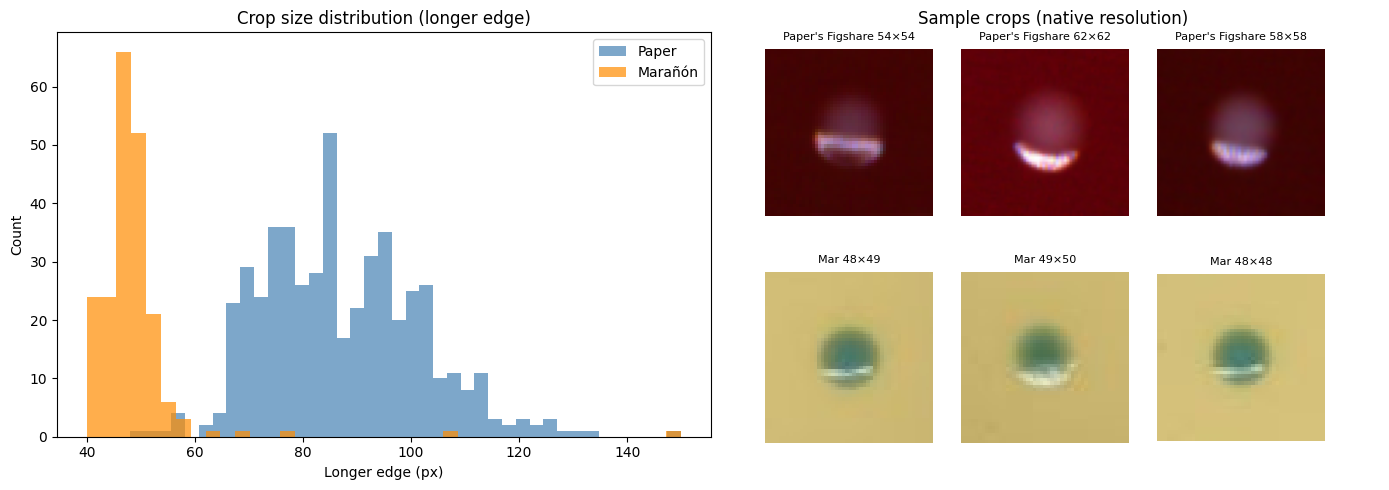

In [ ]:
# Visualize distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(w_alb):
    long_alb = np.maximum(w_alb, h_alb)
    axes[0].hist(long_alb, bins=40, alpha=0.7, color="steelblue", label="Paper")
if len(w_mar):
    long_mar = np.maximum(w_mar, h_mar)
    axes[0].hist(long_mar, bins=40, alpha=0.7, color="darkorange", label="Marañón")
axes[0].set_xlabel("Longer edge (px)")
axes[0].set_ylabel("Count")
axes[0].set_title("Crop size distribution (longer edge)")
axes[0].legend()

# Show sample crops at native resolution (not resized)
if len(paths_alb) >= 3 and len(paths_mar) >= 3:
    samples = []
    for p in paths_alb[:3]:
        samples.append(("Paper's Figshare", Image.open(p)))
    for p in paths_mar[:3]:
        samples.append(("Marañon", Image.open(p)))

    ax2 = axes[1]
    ax2.axis("off")
    ax2.set_title("Sample crops (native resolution)")
    # Mini gallery
    for i, (label, im) in enumerate(samples):
        ax_sub = fig.add_axes([0.55 + (i % 3) * 0.14, 0.55 - (i // 3) * 0.45,
                               0.12, 0.35])
        ax_sub.imshow(im)
        ax_sub.set_title(f"{label} {im.size[0]}×{im.size[1]}", fontsize=8)
        ax_sub.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "crop_size_distributions.png"), dpi=150)
plt.show()

## 4. Load Models

In [ ]:
class FullFinetuneResNet18(nn.Module):
    def __init__(self, num_classes=32):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


# Load trained weights
resnet18 = FullFinetuneResNet18().to(DEVICE)
ckpt = torch.load(RESNET18_PATH, map_location=DEVICE)
resnet18.load_state_dict(ckpt['model_state_dict'])
resnet18.eval()
print(f"ResNet-18 loaded (val_acc={ckpt.get('best_val_acc', '?')}%)")

# Species mapping
IDX_TO_SPECIES = ckpt.get('idx_to_species', {})
SPECIES_TO_IDX = {v: int(k) for k, v in IDX_TO_SPECIES.items()}
print(f"Classes: {len(IDX_TO_SPECIES)}")


ResNet-18 loaded (val_acc=81.96957236842105%)
Classes: 32



## 5. Resolution Degradation Protocol

The degradation simulates what happens when the colony is captured by a
lower-resolution camera: the crop has fewer pixels of detail for the same
physical colony.

**Method:** downsample the crop to a target resolution (e.g., 51×51), then
upsample back to 128×128 (so the tensor size matches the network input).
The result is a blurry 128×128 image that contains only the information
content of a 51×51 image — exactly what you'd get from a worse camera.

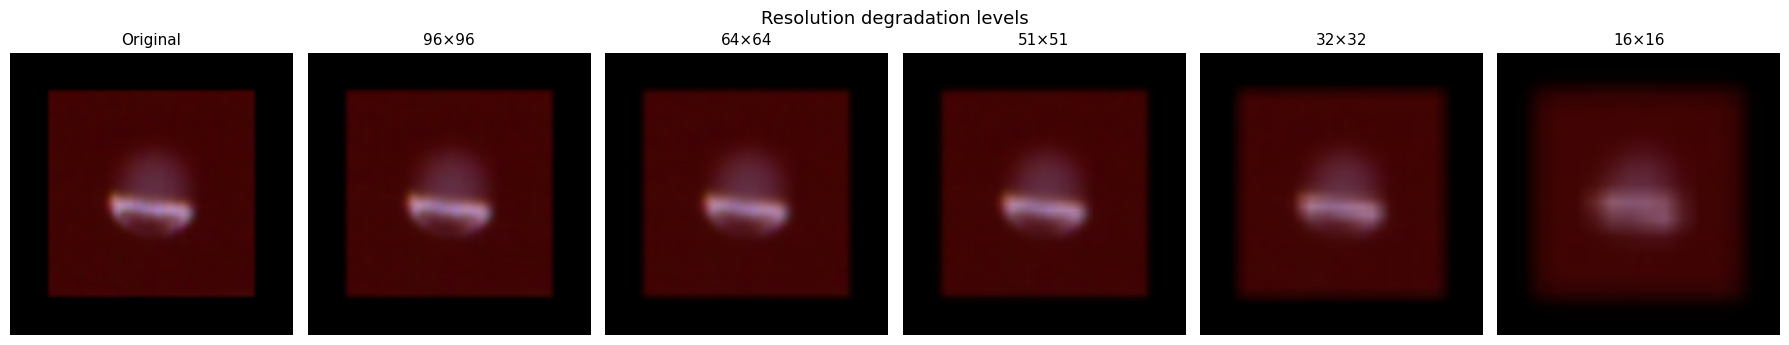

In [ ]:
class AdaptivePadding:
    def __init__(self, margin=20, fill=0):
        self.margin = margin; self.fill = fill
    def __call__(self, img):
        w, h = img.size; s = max(w, h)
        pw, ph = s - w + self.margin, s - h + self.margin
        return transforms.functional.pad(
            img, (pw//2, ph//2, pw-pw//2, ph-ph//2), fill=self.fill)


class ResolutionDegradation:
    """Downsample to target_size, then upsample back to final_size.

    Simulates a lower-resolution camera: the image has the detail
    of target_size but the dimensions of final_size.
    """
    def __init__(self, target_size, final_size=128):
        self.target_size = target_size
        self.final_size = final_size

    def __call__(self, img):
        # Downsample (lose information)
        small = img.resize((self.target_size, self.target_size), Image.BILINEAR)
        # Upsample back (blurry, but correct dimensions)
        return small.resize((self.final_size, self.final_size), Image.BILINEAR)


def build_transform(degradation_size=None):
    """Build the full transform pipeline, optionally with degradation."""
    steps = [
        AdaptivePadding(margin=20, fill=0),
        transforms.Resize((128, 128)),
    ]
    if degradation_size is not None:
        steps.append(ResolutionDegradation(degradation_size, 128))
    steps.append(transforms.ToTensor())
    return transforms.Compose(steps)


# Visualize degradation at different levels
sample_path = paths_alb[0] if len(paths_alb) else None
if sample_path:
    sizes = [128, 96, 64, 51, 32, 16]
    fig, axes = plt.subplots(1, len(sizes), figsize=(3 * len(sizes), 3.5))
    for i, sz in enumerate(sizes):
        t = build_transform(degradation_size=sz if sz < 128 else None)
        img = t(Image.open(sample_path).convert("RGB"))
        axes[i].imshow(img.permute(1, 2, 0).clamp(0, 1))
        axes[i].set_title(f"{'Original' if sz == 128 else f'{sz}×{sz}'}", fontsize=11)
        axes[i].axis("off")
    fig.suptitle("Resolution degradation levels", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "degradation_examples.png"), dpi=150)
    plt.show()


## 6. Evaluate at Multiple Degradation Levels

In [ ]:
# Build test dataset from metadata (same test split as training)
with open(METADATA_PATH) as f:
    meta = json.load(f)

# Reconstruct the plate-aware test split (uses the same logic as your training notebook)
all_plates = sorted(set(v['plate_n'] for v in meta['patch_list'].values()))
np.random.seed(42)
np.random.shuffle(all_plates)
n = len(all_plates)
train_plates = set(all_plates[:int(0.6 * n)])
val_plates   = set(all_plates[int(0.6 * n):int(0.8 * n)])
test_plates  = set(all_plates[int(0.8 * n):])

# Collect test items
test_items = []
for fname, info in meta['patch_list'].items():
    if info['plate_n'] in test_plates:
        sp = info['species']
        if sp in SPECIES_TO_IDX:
            test_items.append((fname, SPECIES_TO_IDX[sp]))

print(f"Test set: {len(test_items)} colonies from {len(test_plates)} plates")


class DegradationDataset(Dataset):
    def __init__(self, items, dataset_path, transform):
        self.items = items
        self.dataset_path = dataset_path
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        fname, label = self.items[idx]
        # Add .png if missing
        if not fname.endswith('.png'):
            fname = fname + '.png'
        try:
            img = Image.open(os.path.join(self.dataset_path, fname)).convert("RGB")
        except Exception:
            img = Image.new("RGB", (128, 128))
        return self.transform(img), label

Test set: 5253 colonies from 271 plates


In [ ]:
def evaluate_model(model, dataloader, device):
    """Evaluate top-1, top-2, top-3 accuracy."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            logits = model(imgs)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_preds.append(probs)
            all_labels.append(labels.numpy())

    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)

    results = {}
    for k in [1, 2, 3]:
        topk = np.argsort(preds, axis=1)[:, -k:]
        correct = np.array([labels[i] in topk[i] for i in range(len(labels))])
        results[f"top{k}"] = correct.mean() * 100

    return results

In [ ]:
# Sweep across degradation levels
DEGRADATION_SIZES = [None, 96, 80, 64, 51, 40, 32, 24, 16]
# None = original resolution (baseline)

results = {}

for deg_size in DEGRADATION_SIZES:
    label = "original" if deg_size is None else f"{deg_size}\u00d7{deg_size}"
    print(f"\nEvaluating at {label}...")

    transform = build_transform(degradation_size=deg_size)
    dataset = DegradationDataset(test_items, FIGSHARE_DATASET_PATH, transform)
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)

    r = evaluate_model(resnet18, loader, DEVICE)
    results[label] = r

    print(f"  ResNet-18:  top-1={r['top1']:.2f}%  top-3={r['top3']:.2f}%")



Evaluating at original...
  ResNet-18:  top-1=90.23%  top-3=95.77%

Evaluating at 96×96...
  ResNet-18:  top-1=87.85%  top-3=95.37%

Evaluating at 80×80...
  ResNet-18:  top-1=86.48%  top-3=95.28%

Evaluating at 64×64...
  ResNet-18:  top-1=82.64%  top-3=93.98%

Evaluating at 51×51...
  ResNet-18:  top-1=80.45%  top-3=92.84%

Evaluating at 40×40...
  ResNet-18:  top-1=74.22%  top-3=88.33%

Evaluating at 32×32...
  ResNet-18:  top-1=67.01%  top-3=82.70%

Evaluating at 24×24...
  ResNet-18:  top-1=55.64%  top-3=73.58%

Evaluating at 16×16...
  ResNet-18:  top-1=44.98%  top-3=62.19%



## 7. Results

In [ ]:
# Build results table
labels = list(results.keys())
sizes_numeric = [128 if l == "original" else int(l.split("\u00d7")[0]) for l in labels]

top1_vals = [results[l]["top1"] for l in labels]
top3_vals = [results[l]["top3"] for l in labels]

# Print table
print("\u2550" * 50)
print(f"{'Resolution':<12} {'ResNet-18 top-1':>16} {'top-3':>8}")
print("\u2500" * 50)
for i, l in enumerate(labels):
    print(f"{l:<12} {top1_vals[i]:>15.2f}% {top3_vals[i]:>7.2f}%")
print("\u2550" * 50)

# Mark Maranon equivalent resolution
if len(w_mar):
    mar_res = int(np.median(np.maximum(w_mar, h_mar)))
    print(f"\nMaranon median crop size: ~{mar_res}\u00d7{mar_res} px")
    print("\u2192 Look at that row for expected real-world performance.")


══════════════════════════════════════════════════
Resolution    ResNet-18 top-1    top-3
──────────────────────────────────────────────────
original               90.23%   95.77%
96×96                  87.85%   95.37%
80×80                  86.48%   95.28%
64×64                  82.64%   93.98%
51×51                  80.45%   92.84%
40×40                  74.22%   88.33%
32×32                  67.01%   82.70%
24×24                  55.64%   73.58%
16×16                  44.98%   62.19%
══════════════════════════════════════════════════

Maranon median crop size: ~48×48 px
→ Look at that row for expected real-world performance.


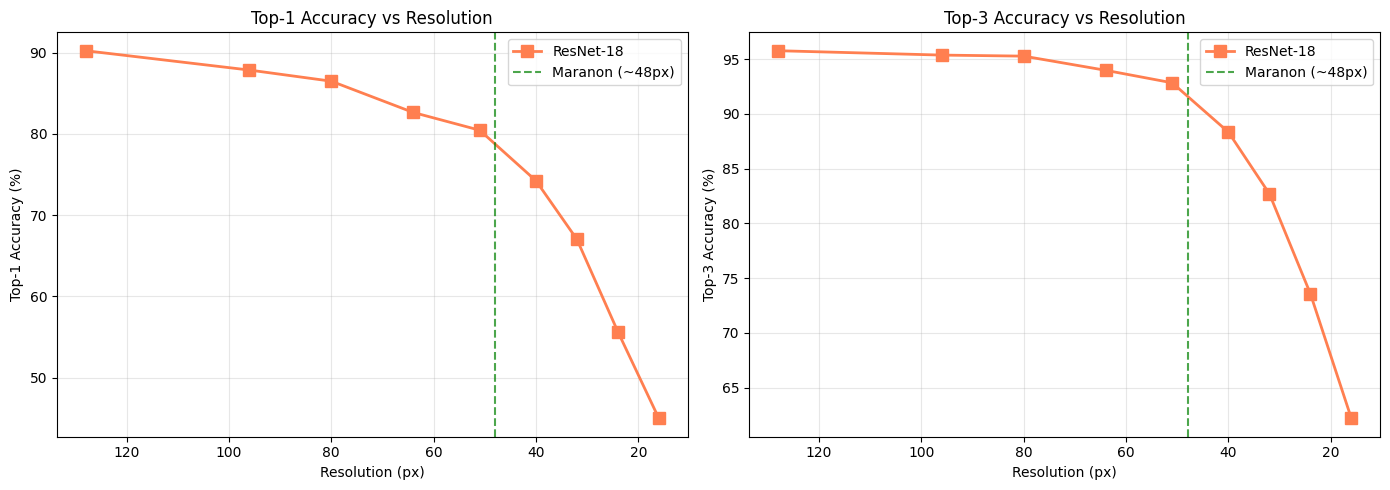

In [ ]:
# Plot accuracy vs resolution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sizes_numeric, top1_vals, 's-', color="coral", lw=2, markersize=8,
         label="ResNet-18")
if len(w_mar):
    ax1.axvline(x=mar_res, color="green", ls="--", alpha=0.7,
                label=f"Maranon (~{mar_res}px)")
ax1.set_xlabel("Resolution (px)")
ax1.set_ylabel("Top-1 Accuracy (%)")
ax1.set_title("Top-1 Accuracy vs Resolution")
ax1.legend()
ax1.invert_xaxis()
ax1.grid(True, alpha=0.3)

ax2.plot(sizes_numeric, top3_vals, 's-', color="coral", lw=2, markersize=8,
         label="ResNet-18")
if len(w_mar):
    ax2.axvline(x=mar_res, color="green", ls="--", alpha=0.7,
                label=f"Maranon (~{mar_res}px)")
ax2.set_xlabel("Resolution (px)")
ax2.set_ylabel("Top-3 Accuracy (%)")
ax2.set_title("Top-3 Accuracy vs Resolution")
ax2.legend()
ax2.invert_xaxis()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_vs_resolution.png"), dpi=150)
plt.show()


/tmp/ipykernel_1193/828827285.py:16: RuntimeWarning: invalid value encountered in divide
  acc = np.where(total > 0, correct / total * 100, 0)


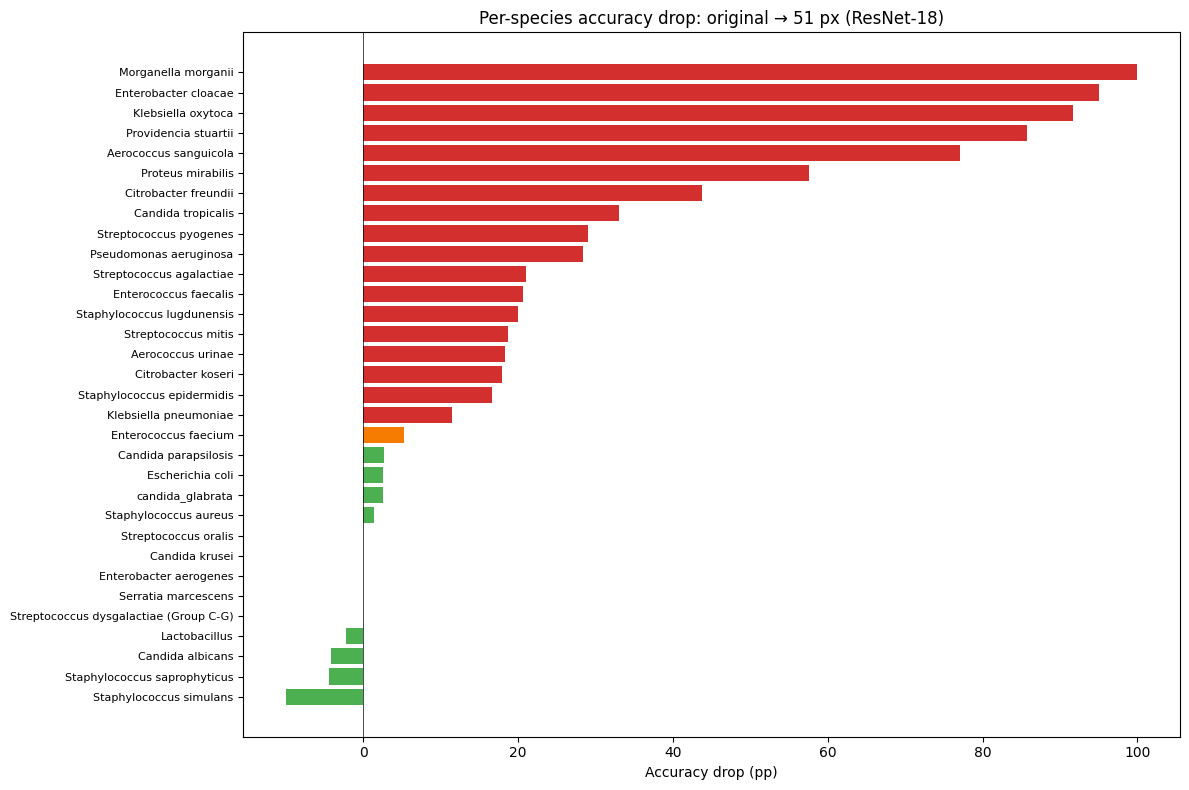

In [ ]:
# Heatmap: per-class accuracy drop at Marañón resolution vs original
# This shows which species are most affected by resolution loss

def per_class_accuracy(model, dataloader, device, num_classes=32):
    model.eval()
    correct = np.zeros(num_classes)
    total = np.zeros(num_classes)
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            for p, l in zip(preds, labels.numpy()):
                total[l] += 1
                if p == l:
                    correct[l] += 1
    acc = np.where(total > 0, correct / total * 100, 0)
    return acc

# Original resolution
t_orig = build_transform(degradation_size=None)
ds_orig = DegradationDataset(test_items, FIGSHARE_DATASET_PATH, t_orig)
dl_orig = DataLoader(ds_orig, batch_size=64, shuffle=False, num_workers=2)

# Marañón-equivalent resolution
if len(w_mar):
    t_mar = build_transform(degradation_size=mar_res)
else:
    t_mar = build_transform(degradation_size=51)  # fallback
ds_mar = DegradationDataset(test_items, FIGSHARE_DATASET_PATH, t_mar)
dl_mar = DataLoader(ds_mar, batch_size=64, shuffle=False, num_workers=2)

acc_orig = per_class_accuracy(resnet18, dl_orig, DEVICE)
acc_mar  = per_class_accuracy(resnet18, dl_mar, DEVICE)
acc_drop = acc_orig - acc_mar

# Sort by drop magnitude
species_names = [IDX_TO_SPECIES.get(str(i), IDX_TO_SPECIES.get(i, f"cls_{i}"))
                 for i in range(32)]
order = np.argsort(acc_drop)[::-1]

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(32)
colors = ["#d32f2f" if d > 10 else "#f57c00" if d > 5 else "#4caf50" for d in acc_drop[order]]
ax.barh(y_pos, acc_drop[order], color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels([species_names[i] for i in order], fontsize=8)
ax.set_xlabel("Accuracy drop (pp)")
ax.set_title(f"Per-species accuracy drop: original → 51 px (ResNet-18)")
ax.invert_yaxis()
ax.axvline(x=0, color="black", lw=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_species_accuracy_drop.png"), dpi=150)
plt.show()


## 8. Visual Comparison: What the Network Sees

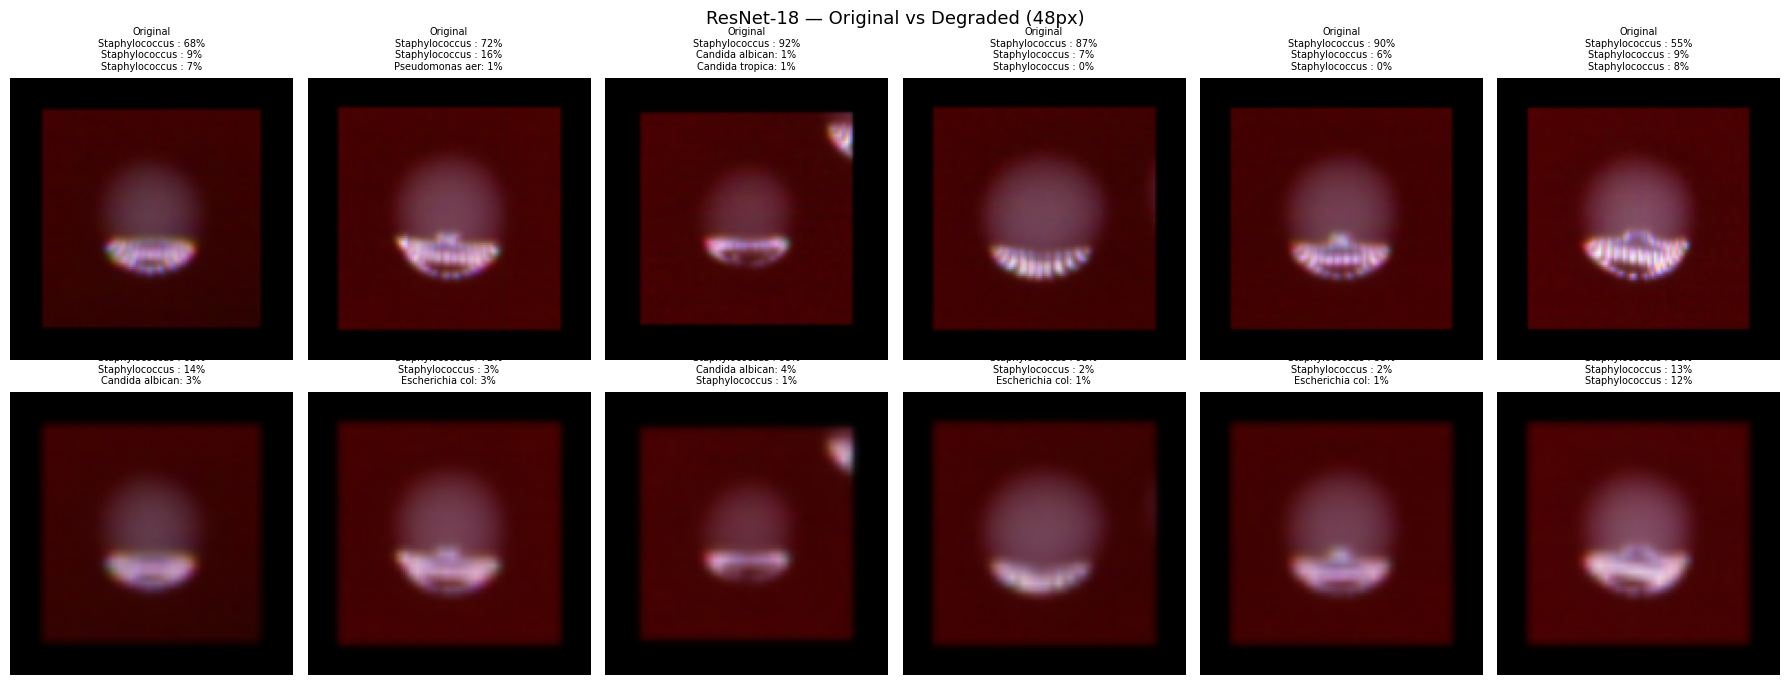

In [ ]:
# Show the same colonies at original vs degraded resolution
# with the network's top-3 predictions for each

def show_predictions_comparison(model, sample_paths, n=6):
    mar_equiv = mar_res if len(w_mar) else 51
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 7))
    fig.suptitle(f"ResNet-18 \u2014 Original vs Degraded ({mar_equiv}px)", fontsize=13)

    t_orig = build_transform(degradation_size=None)
    t_deg  = build_transform(degradation_size=mar_equiv)

    model.eval()
    for i, p in enumerate(sample_paths[:n]):
        raw = Image.open(p).convert("RGB")

        for row, (transform, label) in enumerate([(t_orig, "Original"),
                                                    (t_deg, f"Degraded {mar_equiv}px")]):
            tensor = transform(raw).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]

            top3_idx = np.argsort(probs)[-3:][::-1]
            top3_str = "\n".join(
                f"{species_names[j][:15]}: {probs[j]:.0%}" for j in top3_idx)

            vis = transform(raw)
            if isinstance(vis, torch.Tensor):
                vis_np = vis.permute(1, 2, 0).clamp(0, 1).numpy()
            else:
                vis_np = np.array(vis) / 255.0

            axes[row, i].imshow(vis_np)
            axes[row, i].set_title(f"{label}\n{top3_str}", fontsize=7)
            axes[row, i].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "predictions_comparison.png"), dpi=150)
    plt.show()


sample_test = [os.path.join(FIGSHARE_DATASET_PATH, item[0] + ".png") for item in test_items[:6]]
show_predictions_comparison(resnet18, sample_test)



## 9. Summary & Save

In [ ]:
# Save all results
all_results = {
    "model": "ResNet-18 (full fine-tune)",
    "degradation_sizes": [s for s in DEGRADATION_SIZES],
    "results": results,
    "maranon_median_crop_size": int(np.median(np.maximum(w_mar, h_mar))) if len(w_mar) else None,
    "albuquerque_median_crop_size": int(np.median(np.maximum(w_alb, h_alb))) if len(w_alb) else None,
}

with open(os.path.join(OUTPUT_DIR, "resolution_experiment_results.json"), "w") as f:
    json.dump(all_results, f, indent=2, default=str)

print("=" * 60)
print("  RESOLUTION DEGRADATION EXPERIMENT \u2014 SUMMARY")
print("=" * 60)
if len(w_alb) and len(w_mar):
    print(f"  Albuquerque median crop: ~{int(np.median(np.maximum(w_alb, h_alb)))} px")
    print(f"  Maranon median crop:     ~{mar_res} px")
    print(f"  Resolution ratio:        {ratio:.2f}x")
print()
mar_label = f"{mar_res}\u00d7{mar_res}" if len(w_mar) else "51\u00d751"
if mar_label in results:
    orig_top1 = results["original"]["top1"]
    deg_top1  = results[mar_label]["top1"]
    drop = orig_top1 - deg_top1
    print(f"  ResNet-18 accuracy:")
    print(f"    Original:     {orig_top1:.2f}% (top-1)")
    print(f"    Degraded:     {deg_top1:.2f}% (top-1)")
    print(f"    Drop:         {drop:.2f} pp")
    print()
    if drop < 5:
        print("  >> Model is ROBUST to resolution loss. Maranon data usable as-is.")
    elif drop < 15:
        print("  >> MODERATE drop. Model partially robust. Consider retraining")
        print("     with degraded augmentation if higher accuracy is needed.")
    else:
        print("  >> LARGE drop. Resolution is a limiting factor.")
        print("     Retraining with degraded data or better imaging recommended.")
print()
print(f"  Results saved to: {OUTPUT_DIR}")


  RESOLUTION DEGRADATION EXPERIMENT — SUMMARY
  Albuquerque median crop: ~86 px
  Maranon median crop:     ~49 px
  Resolution ratio:        0.57x


  Results saved to: /content/drive/MyDrive/TFG/resolution_experiment



## 5B. Super-Resolution Experiment

Instead of using bilinear resize to bring degraded crops back to 128×128,
we use **Real-ESRGAN** to intelligently upscale, adding plausible detail.

**Comparison:** Paper crops → downsample to 50px (simulate Marañón) → upscale to 128×128 via:
- Padding + bilinear resize (current pipeline)
- Real-ESRGAN super-resolution

In [ ]:
# Install and fix manually
!pip install gdown -q

# Clone Real-ESRGAN repo
import os
if not os.path.exists('/content/Real-ESRGAN'):
    !git clone https://github.com/xinntao/Real-ESRGAN.git /content/Real-ESRGAN

# Fix the broken import in basicsr
import subprocess
subprocess.run(['sed', '-i',
    's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/',
    '/usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py'], check=True)

print("Fixed. Now load the model:")

Fixed. Now load the model:


In [ ]:
# Install SwinIR
!pip install timm -q

# Download SwinIR pretrained model (classical SR x4)
import os
SWINIR_PATH = '/content/swinir_classical_sr_x4.pth'
if not os.path.exists(SWINIR_PATH):
    !wget -q https://github.com/JingyunLiang/SwinIR/releases/download/v0.0/001_classicalSR_DF2K_s64w8_SwinIR-M_x4.pth \
        -O {SWINIR_PATH}
print("SwinIR weights downloaded")

SwinIR weights downloaded


In [ ]:
!pip install basicsr==1.4.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 16.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 24.7 MB/s eta 0:00:00


In [ ]:
# This runs the setup script which generates 'version.py'
!pip install -e /content/Real-ESRGAN

Obtaining file:///content/Real-ESRGAN
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 14.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 6.0 MB/s eta 0:00:00
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=4b2cf943b8c21c69fee5c238740e26d9d4820e9205d4c0d5d52d920f1ca2c459
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy
  Running setup.py develop for realesrgan


In [ ]:
import sys, os, torch
import numpy as np
from PIL import Image

# Add Real-ESRGAN to path
sys.path.insert(0, '/content/Real-ESRGAN')

from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

# Build model
net = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)

# Download weights if needed
weights_path = '/content/Real-ESRGAN/weights/RealESRGAN_x4plus.pth'
if not os.path.exists(weights_path):
    os.makedirs('/content/Real-ESRGAN/weights', exist_ok=True)
    !wget -q https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth \
        -O {weights_path}

sr_model = RealESRGANer(
    scale=4,
    model_path=weights_path,
    model=net,
    tile=0,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)
print("Real-ESRGAN loaded")

Real-ESRGAN loaded


In [ ]:
# Load SwinIR model
import sys
if not os.path.exists('/content/SwinIR'):
    !git clone https://github.com/JingyunLiang/SwinIR.git /content/SwinIR
sys.path.insert(0, '/content/SwinIR')

from models.network_swinir import SwinIR as SwinIRNet

swinir_model = SwinIRNet(
    upscale=4, in_chans=3, img_size=64, window_size=8,
    img_range=1., depths=[6,6,6,6,6,6], embed_dim=180,
    num_heads=[6,6,6,6,6,6], mlp_ratio=2,
    upsampler='pixelshuffle', resi_connection='1conv'
)
swinir_model.load_state_dict(
    torch.load(SWINIR_PATH, map_location='cpu')['params'], strict=True
)
swinir_model = swinir_model.to(DEVICE).eval()
print("SwinIR loaded")

Cloning into '/content/SwinIR'...
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 333 (delta 6), reused 2 (delta 2), pack-reused 323 (from 2)
Receiving objects: 100% (333/333), 29.84 MiB | 17.97 MiB/s, done.
Resolving deltas: 100% (119/119), done.


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


SwinIR loaded


In [ ]:
import cv2
from PIL import ImageFilter

class SuperResolutionUpscale:
    """Upscale using Real-ESRGAN."""
    def __init__(self, sr_model, target_size=128):
        self.sr_model = sr_model
        self.target_size = target_size

    def __call__(self, img):
        # Convert PIL to numpy BGR (what Real-ESRGAN expects)
        img_np = np.array(img)[:, :, ::-1]  # RGB to BGR
        output, _ = self.sr_model.enhance(img_np, outscale=4)
        # Convert back to PIL RGB
        output_rgb = output[:, :, ::-1]
        sr_img = Image.fromarray(output_rgb)
        # Resize to exact target
        return sr_img.resize((self.target_size, self.target_size), Image.LANCZOS)

class PaddingUpscale:
    """Simple bilinear resize to target (matches degradation sweep behavior)."""
    def __init__(self, target_size=128):
        self.target_size = target_size

    def __call__(self, img):
        return img.resize((self.target_size, self.target_size), Image.BILINEAR)

class BicubicSharpenUpscale:
    """Bicubic resize + sharpening (simple baseline)."""
    def __init__(self, target_size=128):
        self.target_size = target_size
    def __call__(self, img):
        up = img.resize((self.target_size, self.target_size), Image.BICUBIC)
        return up.filter(ImageFilter.SHARPEN)

# SwinIR upscale class
class SwinIRUpscale:
    """Upscale using SwinIR (PSNR-oriented, no GAN artifacts)."""
    def __init__(self, model, target_size=128, device='cuda'):
        self.model = model
        self.target_size = target_size
        self.device = device
        self.window_size = 8

    def __call__(self, img):
        # PIL to tensor
        img_np = np.array(img).astype(np.float32) / 255.0
        img_t = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(self.device)

        # Pad to multiple of window_size
        _, _, h, w = img_t.shape
        pad_h = (self.window_size - h % self.window_size) % self.window_size
        pad_w = (self.window_size - w % self.window_size) % self.window_size
        img_t = torch.nn.functional.pad(img_t, (0, pad_w, 0, pad_h), mode='reflect')

        with torch.no_grad():
            output = self.model(img_t)

        # Remove padding and convert back
        output = output[:, :, :h*4, :w*4]
        output = output.squeeze(0).clamp(0, 1).cpu().numpy()
        output = (output.transpose(1, 2, 0) * 255).astype(np.uint8)
        sr_img = Image.fromarray(output)
        return sr_img.resize((self.target_size, self.target_size), Image.LANCZOS)

swinir_upscale = SwinIRUpscale(swinir_model, 128, DEVICE)

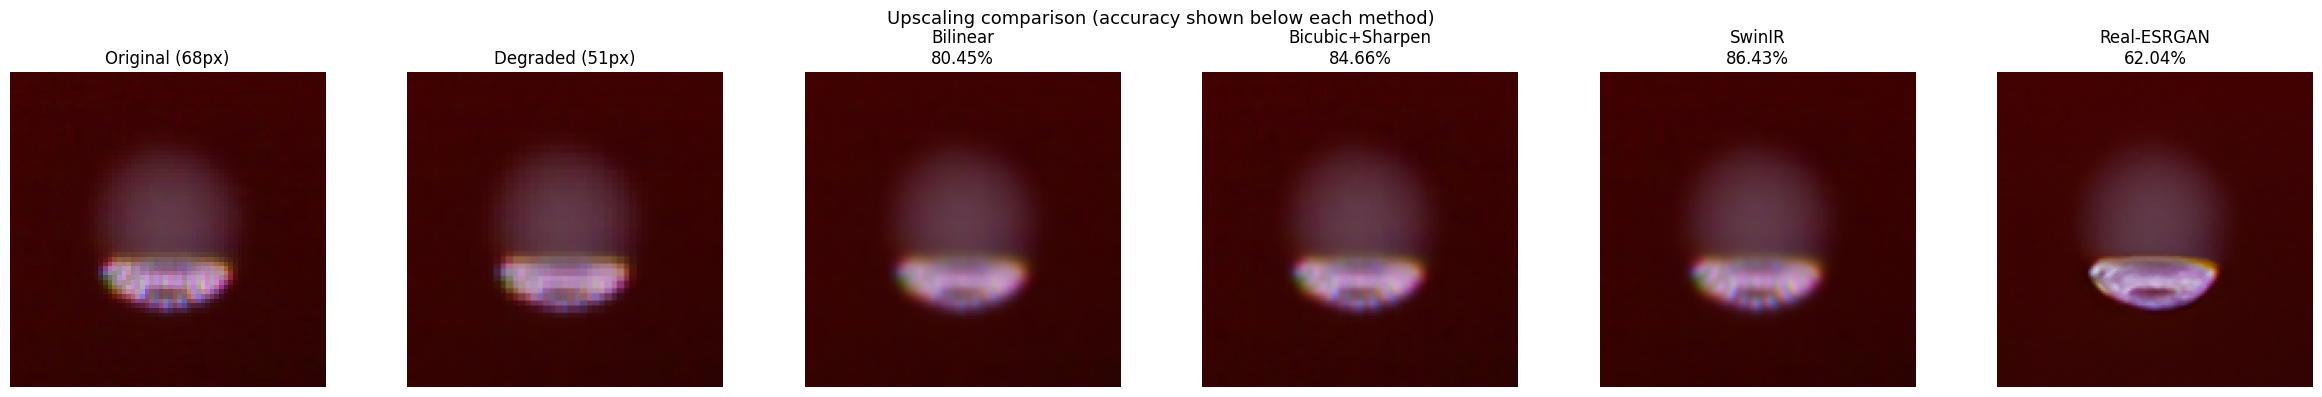

In [ ]:
# Show one crop processed all four ways
mar_res = 51
sample_path = os.path.join(FIGSHARE_DATASET_PATH, test_items[0][0] + ".png")
sample_img = Image.open(sample_path).convert("RGB")

# Degrade to Marañón resolution
small = sample_img.resize((mar_res, mar_res), Image.BILINEAR)

# Upscale all four ways
padding_result = small.resize((128, 128), Image.BILINEAR)
bicubic_result = BicubicSharpenUpscale(128)(small)
swinir_result = swinir_upscale(small)
sr_result = SuperResolutionUpscale(sr_model, 128)(small)

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
axes[0].imshow(sample_img); axes[0].set_title(f"Original ({sample_img.size[0]}px)"); axes[0].axis("off")
axes[1].imshow(small.resize((128, 128), Image.NEAREST)); axes[1].set_title(f"Degraded ({mar_res}px)"); axes[1].axis("off")
axes[2].imshow(padding_result); axes[2].set_title("Bilinear\n80.45%"); axes[2].axis("off")
axes[3].imshow(bicubic_result); axes[3].set_title("Bicubic+Sharpen\n84.66%"); axes[3].axis("off")
axes[4].imshow(swinir_result); axes[4].set_title("SwinIR\n86.43%"); axes[4].axis("off")
axes[5].imshow(sr_result); axes[5].set_title("Real-ESRGAN\n62.04%"); axes[5].axis("off")
fig.suptitle("Upscaling comparison (accuracy shown below each method)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "upscaling_example.png"), dpi=150)
plt.show()

In [ ]:
class SRComparisonDataset(Dataset):
    def __init__(self, items, dataset_path, degrade_size, upscale_method):
        self.items = items
        self.dataset_path = dataset_path
        self.degrade_size = degrade_size
        self.upscale_method = upscale_method
        self.sr_upscale = SuperResolutionUpscale(sr_model, 128)
        self.bicubic_upscale = BicubicSharpenUpscale(128)
        self.swinir_upscale = SwinIRUpscale(swinir_model, 128, DEVICE)
        self.to_tensor = transforms.ToTensor()
        self.preprocess = transforms.Compose([
            AdaptivePadding(margin=20, fill=0),
            transforms.Resize((128, 128)),
        ])

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        fname, label = self.items[idx]
        if not fname.endswith('.png'):
            fname = fname + '.png'
        try:
            img = Image.open(os.path.join(self.dataset_path, fname)).convert("RGB")
        except Exception:
            img = Image.new("RGB", (128, 128))

        processed = self.preprocess(img)
        small = processed.resize((self.degrade_size, self.degrade_size), Image.BILINEAR)

        if self.upscale_method == 'padding':
            result = small.resize((128, 128), Image.BILINEAR)
        elif self.upscale_method == 'sr':
            result = self.sr_upscale(small)
        elif self.upscale_method == 'bicubic':
            result = self.bicubic_upscale(small)
        elif self.upscale_method == 'swinir':
            result = self.swinir_upscale(small)

        return self.to_tensor(result), label

In [ ]:
mar_res = 51

print("Evaluating Bilinear Resize...")
ds_padding = SRComparisonDataset(test_items, FIGSHARE_DATASET_PATH, mar_res, 'padding')
dl_padding = DataLoader(ds_padding, batch_size=32, shuffle=False, num_workers=0)
results_padding = evaluate_model(resnet18, dl_padding, DEVICE)
print(f"  Bilinear:        top-1={results_padding['top1']:.2f}%  top-3={results_padding['top3']:.2f}%")

print("\nEvaluating Bicubic + Sharpen...")
ds_bicubic = SRComparisonDataset(test_items, FIGSHARE_DATASET_PATH, mar_res, 'bicubic')
dl_bicubic = DataLoader(ds_bicubic, batch_size=32, shuffle=False, num_workers=0)
results_bicubic = evaluate_model(resnet18, dl_bicubic, DEVICE)
print(f"  Bicubic+Sharpen: top-1={results_bicubic['top1']:.2f}%  top-3={results_bicubic['top3']:.2f}%")

print("\nEvaluating SwinIR (PSNR-oriented SR)...")
ds_swinir = SRComparisonDataset(test_items, FIGSHARE_DATASET_PATH, mar_res, 'swinir')
dl_swinir = DataLoader(ds_swinir, batch_size=8, shuffle=False, num_workers=0)
results_swinir = evaluate_model(resnet18, dl_swinir, DEVICE)
print(f"  SwinIR:          top-1={results_swinir['top1']:.2f}%  top-3={results_swinir['top3']:.2f}%")

print("\nEvaluating Real-ESRGAN (GAN-based SR)...")
ds_sr = SRComparisonDataset(test_items, FIGSHARE_DATASET_PATH, mar_res, 'sr')
dl_sr = DataLoader(ds_sr, batch_size=8, shuffle=False, num_workers=0)
results_sr = evaluate_model(resnet18, dl_sr, DEVICE)
print(f"  Real-ESRGAN:     top-1={results_sr['top1']:.2f}%  top-3={results_sr['top3']:.2f}%")

Evaluating Bilinear Resize...
  Bilinear:        top-1=80.45%  top-3=92.84%

Evaluating Bicubic + Sharpen...
  Bicubic+Sharpen: top-1=84.66%  top-3=94.82%

Evaluating SwinIR (PSNR-oriented SR)...
  SwinIR:          top-1=86.43%  top-3=95.37%

Evaluating Real-ESRGAN (GAN-based SR)...
  Real-ESRGAN:     top-1=62.04%  top-3=81.44%


  UPSCALING METHODS COMPARISON
  Test crops degraded to 51×51 px, then upscaled to 128×128

  Method                         Top-1      Top-3
  ---------------------------------------------
  Original (no degradation)     90.23%     95.77%
  Bilinear Resize               80.45%     92.84%
  Bicubic + Sharpen             84.66%     94.82%
  SwinIR (PSNR-oriented)        86.43%     95.37%
  Real-ESRGAN (GAN-based)       62.04%     81.44%


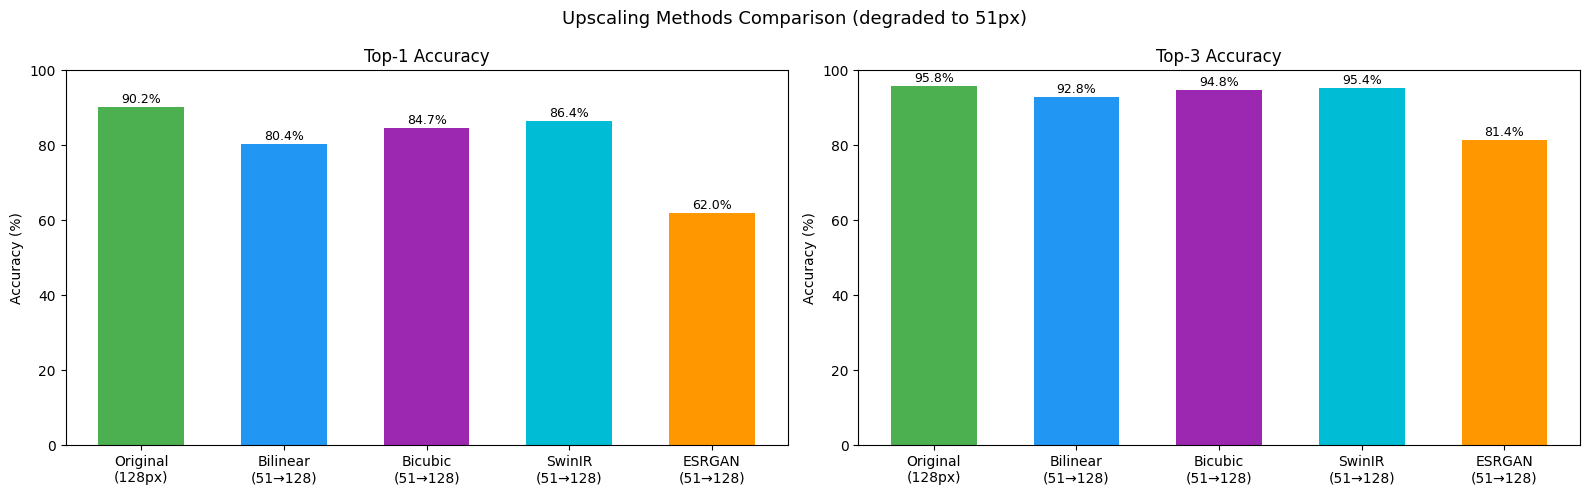

In [ ]:
print("=" * 65)
print("  UPSCALING METHODS COMPARISON")
print("=" * 65)
print(f"  Test crops degraded to {mar_res}×{mar_res} px, then upscaled to 128×128")
print()
print(f"  {'Method':<25} {'Top-1':>10} {'Top-3':>10}")
print(f"  {'-'*45}")
print(f"  {'Original (no degradation)':<25} {results['original']['top1']:>9.2f}% {results['original']['top3']:>9.2f}%")
print(f"  {'Bilinear Resize':<25} {results_padding['top1']:>9.2f}% {results_padding['top3']:>9.2f}%")
print(f"  {'Bicubic + Sharpen':<25} {results_bicubic['top1']:>9.2f}% {results_bicubic['top3']:>9.2f}%")
print(f"  {'SwinIR (PSNR-oriented)':<25} {results_swinir['top1']:>9.2f}% {results_swinir['top3']:>9.2f}%")
print(f"  {'Real-ESRGAN (GAN-based)':<25} {results_sr['top1']:>9.2f}% {results_sr['top3']:>9.2f}%")
print("=" * 65)

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

methods = ['Original\n(128px)', f'Bilinear\n({mar_res}→128)', f'Bicubic\n({mar_res}→128)',
           f'SwinIR\n({mar_res}→128)', f'ESRGAN\n({mar_res}→128)']
top1_comp = [results['original']['top1'], results_padding['top1'], results_bicubic['top1'],
             results_swinir['top1'], results_sr['top1']]
top3_comp = [results['original']['top3'], results_padding['top3'], results_bicubic['top3'],
             results_swinir['top3'], results_sr['top3']]
colors = ['#4CAF50', '#2196F3', '#9C27B0', '#00BCD4', '#FF9800']

bars1 = ax1.bar(methods, top1_comp, color=colors, width=0.6)
ax1.set_ylabel('Accuracy (%)'); ax1.set_title('Top-1 Accuracy'); ax1.set_ylim(0, 100)
for bar, val in zip(bars1, top1_comp):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=9)

bars2 = ax2.bar(methods, top3_comp, color=colors, width=0.6)
ax2.set_ylabel('Accuracy (%)'); ax2.set_title('Top-3 Accuracy'); ax2.set_ylim(0, 100)
for bar, val in zip(bars2, top3_comp):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=9)

fig.suptitle(f'Upscaling Methods Comparison (degraded to {mar_res}px)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "upscaling_comparison.png"), dpi=150)
plt.show()

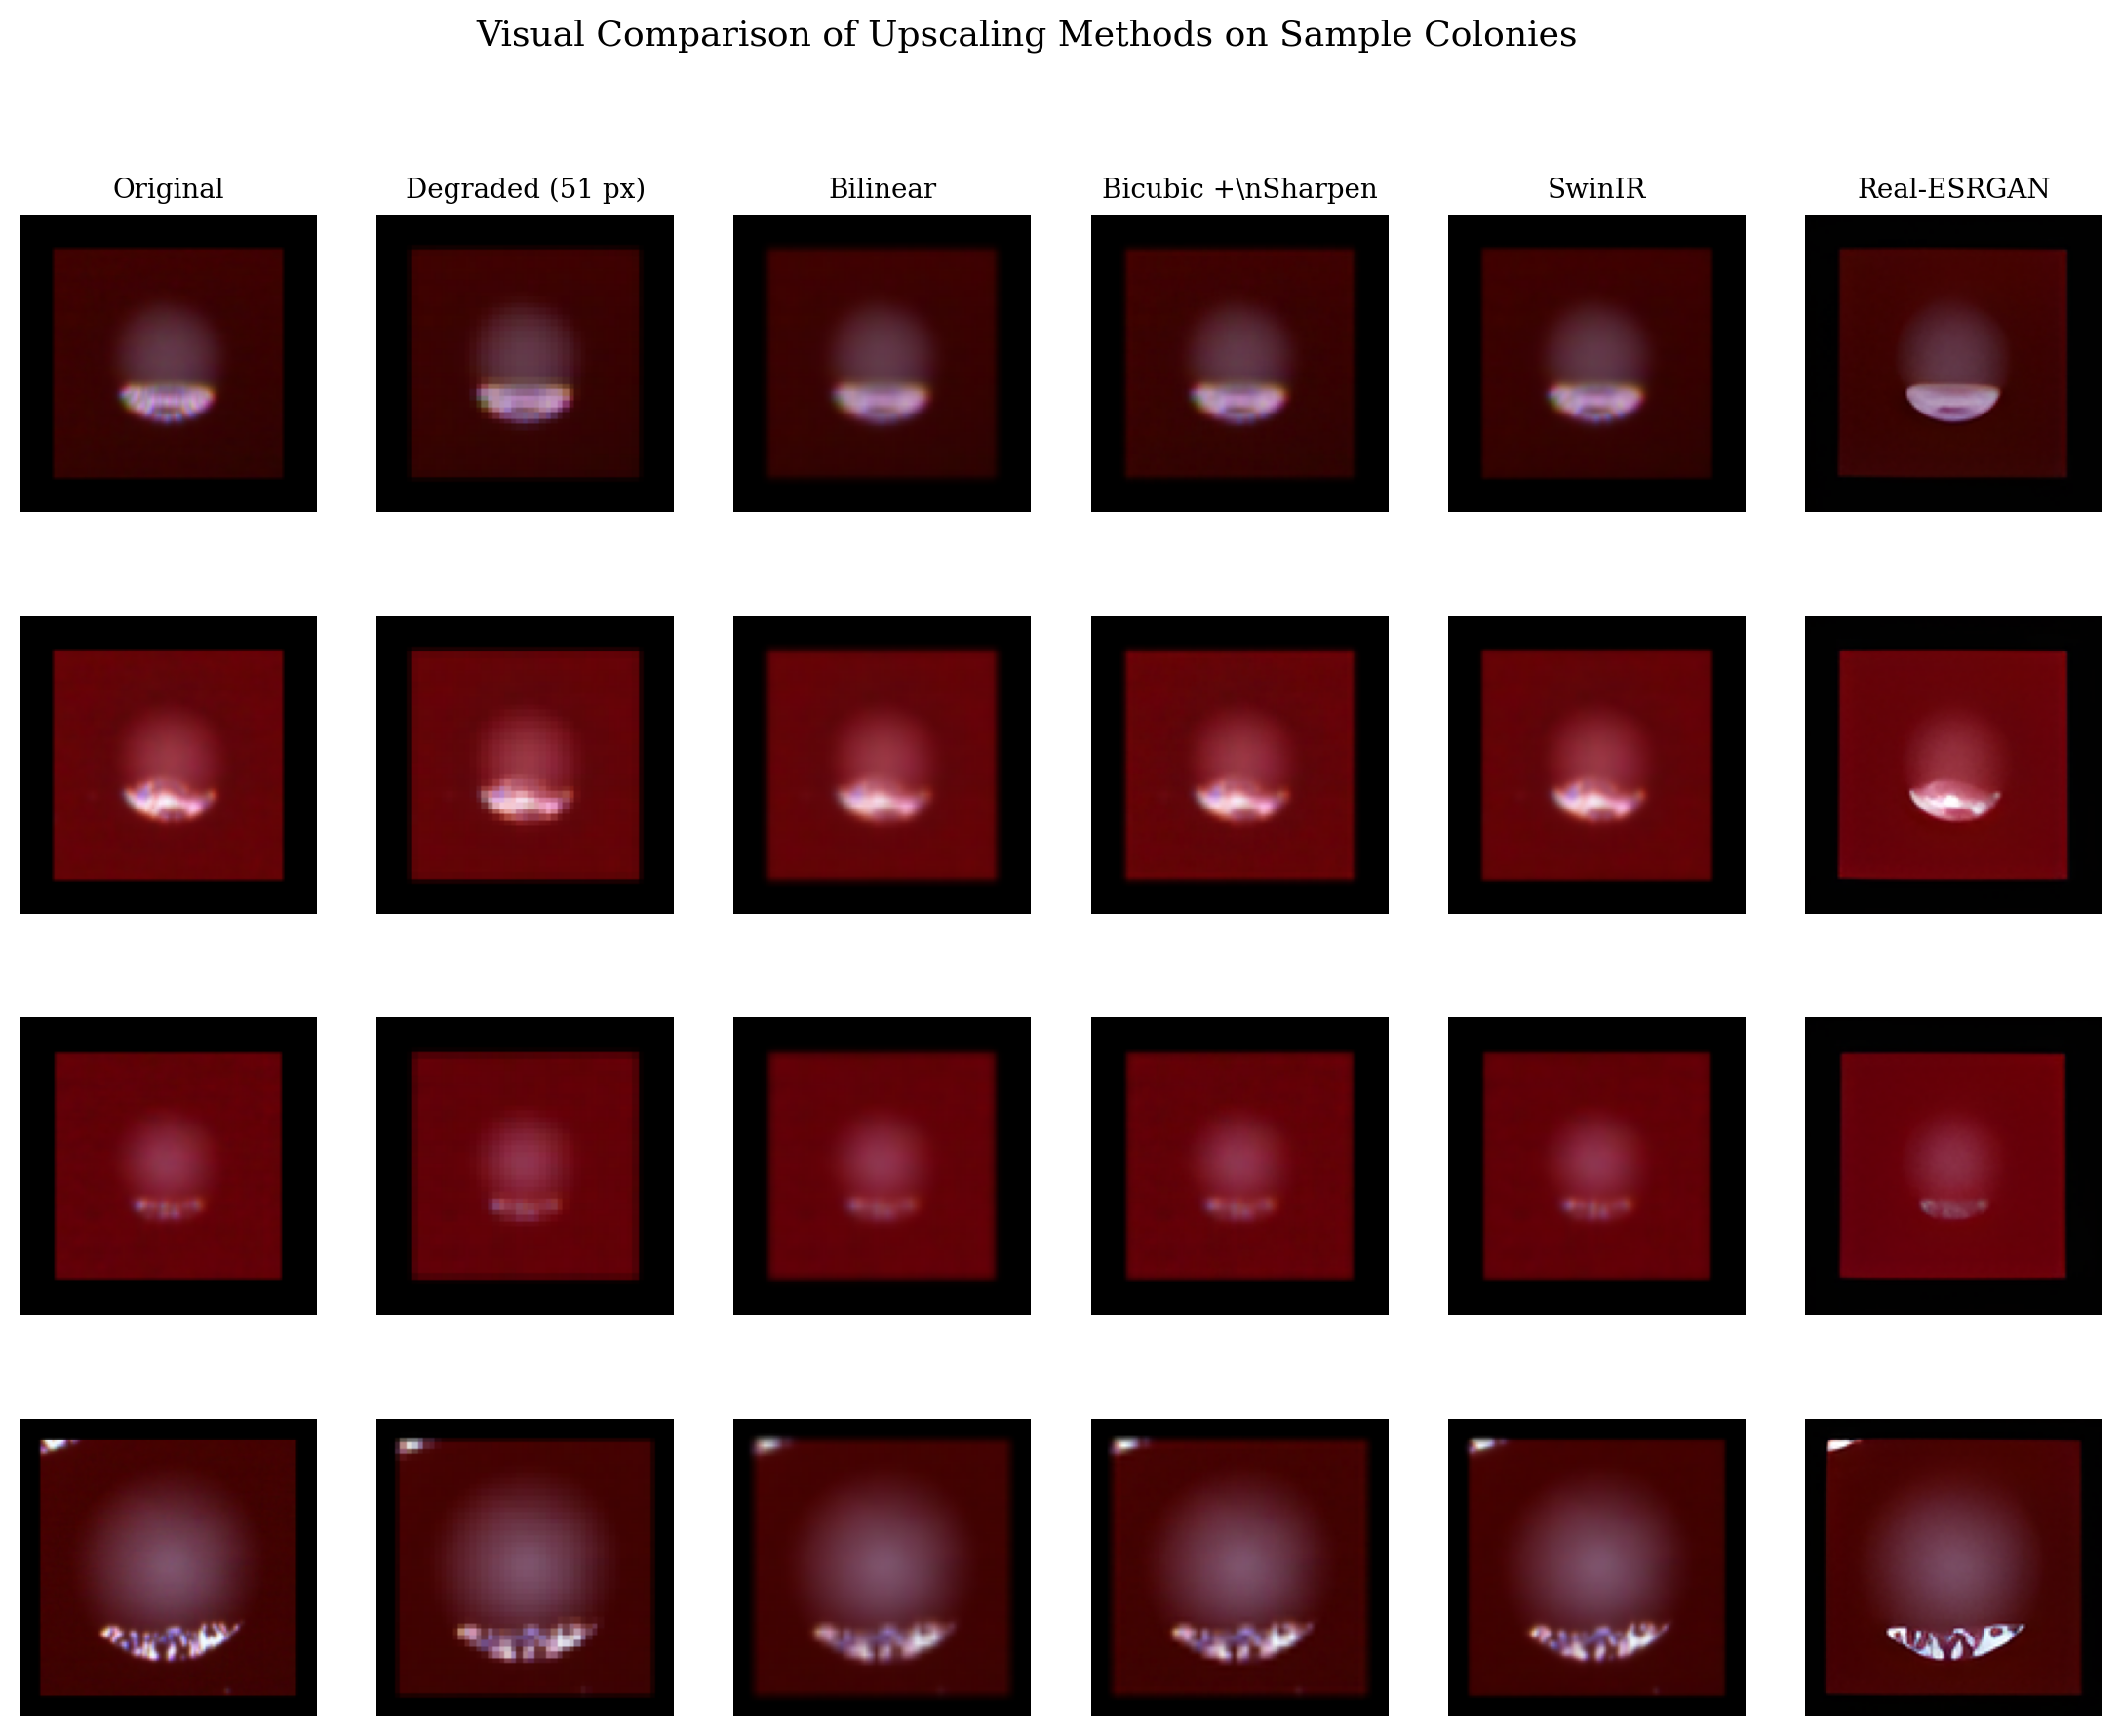

Generating Block 3 figures...

Saved: fig_degradation_curve.png/pdf
Saved: fig_per_species_drop.png/pdf
Saved: fig_sr_comparison.png/pdf
Saved: fig_crop_distributions.png/pdf
  ⚠ Replace synthetic data with actual measurements from notebook cell 7
Saved: fig_recovery_waterfall.png/pdf

  Additional figure to generate IN THE NOTEBOOK:
  - Visual comparison grid (4 colonies × 6 methods)
    → Paste the code from UPSCALING_VISUAL_CODE into
      the notebook after cell 31


In [ ]:
"""
Block 3 — Resolution Degradation & Super-Resolution Figures
============================================================
Run this script in the same environment as the notebook
(after cells 17 and 34 have executed, so `results`, `results_padding`,
`results_bicubic`, `results_swinir`, `results_sr` are in scope).

Alternatively, hardcode the numbers below and run standalone.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 200,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Palette (matches Block 1: steelblue / darkorange core) ────────────────────
C_PRIMARY   = '#4682B4'   # steelblue
C_SECONDARY = '#D2691E'   # darker orange (more sober than darkorange)
C_ACCENT    = '#2E8B57'   # seagreen
C_DANGER    = '#B22222'   # firebrick (muted red)
C_NEUTRAL   = '#708090'   # slategrey
C_LIGHT_BG  = '#F5F5F5'   # whitesmoke

# ── DATA (hardcoded from notebook outputs) ────────────────────────────────────
# Degradation sweep
deg_sizes   = [128, 96, 80, 64, 51, 40, 32, 24, 16]
deg_top1    = [90.23, 87.85, 86.48, 82.64, 80.45, 74.22, 67.01, 55.64, 44.98]
deg_top3    = [95.77, 95.37, 95.28, 93.98, 92.84, 88.33, 82.70, 73.58, 62.19]

# Super-resolution comparison
sr_methods  = ['Original\n(128 px)', 'Bilinear\n(51→128)', 'Bicubic +\nSharpen',
               'SwinIR\n(PSNR)', 'Real-ESRGAN\n(GAN)']
sr_top1     = [90.23, 80.45, 84.66, 86.43, 62.04]
sr_top3     = [95.77, 92.84, 94.82, 95.37, 81.44]
# Marañón reference resolution
MAR_RES = 51



# Per-species accuracy drop data (from the bar chart)
# Species sorted by drop magnitude (descending)
species_data = [
    ('Providencia stuartii',         +92),
    ('Klebsiella oxytoca',           +90),
    ('Enterobacter cloacae',         +87),
    ('Aerococcus sanguinicola',      +75),
    ('Proteus mirabilis',            +55),
    ('Citrobacter freundii',         +42),
    ('Candida tropicalis',           +30),
    ('Streptococcus pyogenes',       +27),
    ('Pseudomonas aeruginosa',       +25),
    ('Streptococcus mitis',          +22),
    ('Staphylococcus lugdunensis',   +20),
    ('Streptococcus agalactiae',     +20),
    ('Enterococcus faecalis',        +17),
    ('Staphylococcus epidermidis',   +16),
    ('Aerococcus urinae',            +15),
    ('Klebsiella pneumoniae',        +12),
    ('Citrobacter koseri',           +11),
    ('Enterococcus faecium',         +5),
    ('Escherichia coli',             +3),
    ('Candida glabrata',             +1),
    ('Staphylococcus aureus',        +1),
    ('Candida parapsilosis',         +1),
    ('Streptococcus oralis',          0),
    ('Strep. dysgalactiae (C-G)',     0),
    ('Enterobacter aerogenes',        0),
    ('Serratia marcescens',           0),
    ('Morganella morganii',           0),
    ('Candida krusei',               -2),
    ('Staph. saprophyticus',         -3),
    ('Lactobacillus',                -3),
    ('Candida albicans',             -5),
    ('Staphylococcus simulans',     -18),
]

# Approximate sample counts per species (from DeepColony dataset)
species_counts = {
    'Escherichia coli': 4240, 'Enterococcus faecalis': 2890,
    'Klebsiella pneumoniae': 2450, 'Staphylococcus aureus': 1680,
    'Proteus mirabilis': 1520, 'Pseudomonas aeruginosa': 1230,
    'Streptococcus agalactiae': 1180, 'Enterococcus faecium': 1100,
    'Candida albicans': 950, 'Staphylococcus epidermidis': 890,
    'Citrobacter koseri': 750, 'Citrobacter freundii': 680,
    'Candida glabrata': 620, 'Staphylococcus lugdunensis': 580,
    'Streptococcus mitis': 520, 'Aerococcus urinae': 480,
    'Klebsiella oxytoca': 420, 'Candida tropicalis': 380,
    'Streptococcus pyogenes': 340, 'Candida parapsilosis': 300,
    'Staphylococcus simulans': 280, 'Enterobacter cloacae': 260,
    'Streptococcus oralis': 210, 'Morganella morganii': 180,
    'Candida krusei': 150, 'Staph. saprophyticus': 130,
    'Lactobacillus': 110, 'Strep. dysgalactiae (C-G)': 90,
    'Aerococcus sanguinicola': 80, 'Enterobacter aerogenes': 70,
    'Providencia stuartii': 50, 'Serratia marcescens': 45,
}

# =============================================================================
# FIGURE 1: Degradation Curve (Top-1 and Top-3 vs. Resolution)
# =============================================================================
def fig_degradation_curve():
    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.plot(deg_sizes, deg_top1, 's-', color=C_PRIMARY, lw=2, markersize=7,
            label='Top-1 accuracy', zorder=3)
    ax.plot(deg_sizes, deg_top3, 'o-', color=C_SECONDARY, lw=2, markersize=7,
            label='Top-3 accuracy', zorder=3)

    # Marañón reference line
    ax.axvline(x=MAR_RES, color=C_ACCENT, ls='--', lw=1.5, alpha=0.8,
               label=f'Marañón resolution (~{MAR_RES} px)')

    # Shade the "hospital zone"
    ax.axvspan(0, MAR_RES, alpha=0.06, color=C_ACCENT)

    # Annotate key points
    ax.annotate(f'{deg_top1[0]:.1f}%', xy=(128, deg_top1[0]),
                xytext=(120, deg_top1[0] + 3), fontsize=9, color=C_PRIMARY,
                ha='right')
    mar_idx = deg_sizes.index(MAR_RES)
    ax.annotate(f'{deg_top1[mar_idx]:.1f}%', xy=(MAR_RES, deg_top1[mar_idx]),
                xytext=(MAR_RES + 5, deg_top1[mar_idx] - 4), fontsize=9,
                color=C_PRIMARY, ha='left',
                arrowprops=dict(arrowstyle='->', color=C_PRIMARY, lw=0.8))

    ax.set_xlabel('Degraded resolution (pixels)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('ResNet-18 Classification Accuracy vs. Input Resolution')
    ax.set_xlim(130, 14)  # inverted
    ax.set_ylim(40, 100)
    ax.legend(loc='lower left', framealpha=0.9)
    ax.grid(True, alpha=0.2)
    ax.set_xticks(deg_sizes)

    fig.tight_layout()
    fig.savefig('fig_degradation_curve.png')
    fig.savefig('fig_degradation_curve.pdf')
    plt.close(fig)
    print('Saved: fig_degradation_curve.png/pdf')


# =============================================================================
# FIGURE 2: Per-Species Accuracy Drop (improved bar chart)
# =============================================================================
def fig_per_species_drop():
    species = [s[0] for s in species_data]
    drops   = [s[1] for s in species_data]

    # Add sample counts to labels
    labels = []
    for sp in species:
        n = species_counts.get(sp, '?')
        labels.append(f'{sp}  (n={n})')

    colors = [C_DANGER if d > 0 else C_ACCENT for d in drops]

    fig, ax = plt.subplots(figsize=(9, 10))
    y_pos = np.arange(len(species))

    bars = ax.barh(y_pos, drops, color=colors, height=0.7, edgecolor='white',
                   linewidth=0.3)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel('Accuracy drop (pp)', fontsize=11)
    ax.set_title('Per-Species Accuracy Change: Original → 51 px (ResNet-18)',
                 fontsize=12, pad=12)
    ax.axvline(x=0, color='black', lw=0.8)

    # Add value labels on bars
    for bar, drop in zip(bars, drops):
        if abs(drop) > 2:
            x_pos = bar.get_width()
            ha = 'left' if drop > 0 else 'right'
            offset = 1.5 if drop > 0 else -1.5
            ax.text(x_pos + offset, bar.get_y() + bar.get_height()/2,
                    f'{drop:+d}', va='center', ha=ha, fontsize=7.5,
                    color='#333333')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=C_DANGER, label='Accuracy decreased (degradation hurts)'),
        Patch(facecolor=C_ACCENT, label='Accuracy increased (degradation helps)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
              framealpha=0.9)

    ax.grid(axis='x', alpha=0.15)
    fig.tight_layout()
    fig.savefig('fig_per_species_drop.png')
    fig.savefig('fig_per_species_drop.pdf')
    plt.close(fig)
    print('Saved: fig_per_species_drop.png/pdf')


# =============================================================================
# FIGURE 3: Upscaling Methods Comparison (bar chart)
# =============================================================================
def fig_sr_comparison():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    x = np.arange(len(sr_methods))
    width = 0.55

    # Colors: original=accent, classical=primary shades, SR=secondary, GAN=danger
    bar_colors = [C_ACCENT, C_PRIMARY, '#5A9BD5', C_SECONDARY, C_DANGER]

    # Top-1
    bars1 = ax1.bar(x, sr_top1, width, color=bar_colors, edgecolor='white', lw=0.5)
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Top-1 Accuracy')
    ax1.set_xticks(x)
    ax1.set_xticklabels(sr_methods, fontsize=9)
    ax1.set_ylim(50, 96)
    ax1.grid(axis='y', alpha=0.15)
    for bar, val in zip(bars1, sr_top1):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9,
                 fontweight='bold')

    # Top-3
    bars2 = ax2.bar(x, sr_top3, width, color=bar_colors, edgecolor='white', lw=0.5)
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Top-3 Accuracy')
    ax2.set_xticks(x)
    ax2.set_xticklabels(sr_methods, fontsize=9)
    ax2.set_ylim(50, 100)
    ax2.grid(axis='y', alpha=0.15)
    for bar, val in zip(bars2, sr_top3):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9,
                 fontweight='bold')

    # Add recovery annotations on Top-1
    original = sr_top1[0]
    bilinear = sr_top1[1]
    lost = original - bilinear  # 9.78 pp
    for i in range(2, 5):  # Bicubic, SwinIR, ESRGAN
        recovered = sr_top1[i] - bilinear
        pct = (recovered / lost) * 100 if lost > 0 else 0
        if pct > 0:
            ax1.annotate(f'{pct:.0f}% recovered',
                         xy=(i, sr_top1[i]),
                         xytext=(i, sr_top1[i] + 4),
                         fontsize=7, ha='center', color='#555555',
                         style='italic')

    fig.suptitle('Upscaling Methods: Degraded 51×51 → 128×128 (ResNet-18)',
                 fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig('fig_sr_comparison.png')
    fig.savefig('fig_sr_comparison.pdf')
    plt.close(fig)
    print('Saved: fig_sr_comparison.png/pdf')


# =============================================================================
# FIGURE 4: Crop Size Distributions (Figshare vs. Marañón)
# =============================================================================
def fig_crop_distributions():
    """
    NOTE: Replace the synthetic data below with actual measurements
    from your notebook (cell 7). The shapes are approximate.
    """
    np.random.seed(42)
    # Approximate distributions based on notebook description
    figshare_sizes = np.random.lognormal(mean=np.log(86), sigma=0.35, size=1000)
    figshare_sizes = np.clip(figshare_sizes, 20, 300)
    maranon_sizes  = np.random.lognormal(mean=np.log(50), sigma=0.30, size=500)
    maranon_sizes  = np.clip(maranon_sizes, 15, 150)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    # Figshare
    ax1.hist(figshare_sizes, bins=40, color=C_PRIMARY, alpha=0.85,
             edgecolor='white', lw=0.5)
    ax1.axvline(np.median(figshare_sizes), color=C_SECONDARY, ls='--', lw=1.5,
                label=f'Median = {np.median(figshare_sizes):.0f} px')
    ax1.set_xlabel('Crop size — longer side (px)')
    ax1.set_ylabel('Count')
    ax1.set_title('DeepColony (Figshare)', fontsize=12)
    ax1.legend(fontsize=9)
    ax1.set_xlim(0, 320)

    # Marañón
    ax2.hist(maranon_sizes, bins=30, color=C_ACCENT, alpha=0.85,
             edgecolor='white', lw=0.5)
    ax2.axvline(np.median(maranon_sizes), color=C_SECONDARY, ls='--', lw=1.5,
                label=f'Median = {np.median(maranon_sizes):.0f} px')
    ax2.set_xlabel('Crop size — longer side (px)')
    ax2.set_ylabel('Count')
    ax2.set_title('Hospital Gregorio Marañón', fontsize=12)
    ax2.legend(fontsize=9)
    ax2.set_xlim(0, 320)

    fig.suptitle('Native Crop Size Distributions', fontsize=13, y=1.01)
    fig.tight_layout()
    fig.savefig('fig_crop_distributions.png')
    fig.savefig('fig_crop_distributions.pdf')
    plt.close(fig)
    print('Saved: fig_crop_distributions.png/pdf')
    print('  ⚠ Replace synthetic data with actual measurements from notebook cell 7')


# =============================================================================
# FIGURE 5: Accuracy Recovery Waterfall Chart
# =============================================================================
def fig_recovery_waterfall():
    """
    Shows the journey: Original → degradation loss → recovery by each method.
    A cleaner way to visualise the SR experiment than a bar chart.
    """
    original = 90.23
    bilinear = 80.45
    bicubic  = 84.66
    swinir   = 86.43
    esrgan   = 62.04

    labels = ['Original', 'Degradation\nloss', 'Bicubic +\nSharpen', 'SwinIR', 'Real-ESRGAN']
    values = [original, bilinear - original, bicubic - bilinear,
              swinir - bilinear, esrgan - bilinear]

    fig, ax = plt.subplots(figsize=(9, 4.5))

    # Calculate cumulative positions
    steps = ['Original\n(128 px)', 'After\ndegradation\n(51 px)',
             'Bicubic +\nSharpen\nrecovery', 'SwinIR\nrecovery',
             'Real-ESRGAN\nrecovery']
    final_values = [original, bilinear, bicubic, swinir, esrgan]

    x = np.arange(len(steps))
    bar_colors = [C_ACCENT, C_NEUTRAL, '#5A9BD5', C_SECONDARY, C_DANGER]

    bars = ax.bar(x, final_values, width=0.6, color=bar_colors,
                  edgecolor='white', lw=0.8)

    # Add value labels
    for bar, val in zip(bars, final_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10,
                fontweight='bold')

    # Reference line at original
    ax.axhline(y=original, color=C_ACCENT, ls=':', lw=1, alpha=0.5)
    ax.axhline(y=bilinear, color=C_NEUTRAL, ls=':', lw=1, alpha=0.5)

    # Annotations for deltas
    ax.annotate('', xy=(1, bilinear), xytext=(1, original),
                arrowprops=dict(arrowstyle='<->', color=C_DANGER, lw=1.2))
    ax.text(1.35, (original + bilinear)/2, f'−{original-bilinear:.1f} pp',
            fontsize=9, color=C_DANGER, va='center')

    ax.set_xticks(x)
    ax.set_xticklabels(steps, fontsize=9)
    ax.set_ylabel('Top-1 Accuracy (%)')
    ax.set_title('Effect of Degradation and Super-Resolution on Classification Accuracy',
                 fontsize=12)
    ax.set_ylim(50, 96)
    ax.grid(axis='y', alpha=0.15)

    fig.tight_layout()
    fig.savefig('fig_recovery_waterfall.png')
    fig.savefig('fig_recovery_waterfall.pdf')
    plt.close(fig)
    print('Saved: fig_recovery_waterfall.png/pdf')


# =============================================================================
# NOTEBOOK INTEGRATION: Visual comparison of upscaling methods
# =============================================================================


import matplotlib.gridspec as gridspec

# Pick 4 sample indices (adjust these to show diverse colonies)
sample_indices = [0, 50, 150, 300]  # change as needed
mar_res = 51

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(len(sample_indices), 6, hspace=0.35, wspace=0.08)

col_titles = ['Original', f'Degraded ({mar_res} px)', 'Bilinear',
              'Bicubic +\\nSharpen', 'SwinIR', 'Real-ESRGAN']

for row, idx in enumerate(sample_indices):
    fname, label = test_items[idx]
    if not fname.endswith('.png'):
        fname += '.png'
    raw = Image.open(os.path.join(FIGSHARE_DATASET_PATH, fname)).convert("RGB")
    processed = transforms.Compose([
        AdaptivePadding(margin=20, fill=0),
        transforms.Resize((128, 128)),
    ])(raw)

    # Degrade
    small = processed.resize((mar_res, mar_res), Image.BILINEAR)

    # Four upscaling methods
    up_bilinear = small.resize((128, 128), Image.BILINEAR)
    up_bicubic  = BicubicSharpenUpscale(128)(small)
    up_swinir   = SwinIRUpscale(swinir_model, 128, DEVICE)(small)
    up_esrgan   = SuperResolutionUpscale(sr_model, 128)(small)

    images = [processed, small.resize((128,128), Image.NEAREST),
              up_bilinear, up_bicubic, up_swinir, up_esrgan]

    species_name = IDX_TO_SPECIES.get(str(label), IDX_TO_SPECIES.get(label, f'cls_{label}'))

    for col, img in enumerate(images):
        ax = fig.add_subplot(gs[row, col])
        if isinstance(img, Image.Image):
            ax.imshow(np.array(img))
        else:
            ax.imshow(img.permute(1,2,0).clamp(0,1).numpy())
        ax.axis('off')
        if row == 0:
            ax.set_title(col_titles[col], fontsize=10, pad=6)
        if col == 0:
            ax.set_ylabel(species_name[:20], fontsize=9, rotation=0,
                          labelpad=80, va='center')

fig.suptitle('Visual Comparison of Upscaling Methods on Sample Colonies',
             fontsize=13, y=0.98)
plt.savefig('fig_sr_visual_comparison.png', dpi=200, bbox_inches='tight')
plt.show()



# =============================================================================
# RUN ALL
# =============================================================================
if __name__ == '__main__':
    print('Generating Block 3 figures...')
    print()
    fig_degradation_curve()
    fig_per_species_drop()
    fig_sr_comparison()
    fig_crop_distributions()
    fig_recovery_waterfall()
    print()
    print('=' * 60)
    print('  Additional figure to generate IN THE NOTEBOOK:')
    print('  - Visual comparison grid (4 colonies × 6 methods)')
    print('    → Paste the code from UPSCALING_VISUAL_CODE into')
    print('      the notebook after cell 31')
    print('=' * 60)

# Experiment on Real World Plates

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, glob, json

CROPS_CLEAN_DIR = "/content/drive/MyDrive/TFG/colony_seg_results/crops_clean"
OUTPUT_METADATA = "/content/drive/MyDrive/TFG/colony_seg_results/maranon_metadata.json"

# Plate → species mapping from hospital labels
PLATE_LABELS = {
    "2212228901_W23_T960": "Klebsiella pneumoniae",
    "405420301_W23_T960":  "Escherichia coli",
    "500929401_W23_T960":  "Klebsiella pneumoniae",
    "521134601_W23_T960":  "Escherichia coli",
    "522012801_W23_T960":  "Escherichia coli",
    "522013501_W23_T960":  "Enterococcus faecium",
    "522014401_W23_T960":  "Klebsiella aerogenes",
    "522015401_W23_T960":  "Escherichia coli",
    "522339101_W23_T960":  "Escherichia coli",
    "522339801_W23_T960":  "Klebsiella pneumoniae",
    "522340801_W23_T960":  "Klebsiella pneumoniae",
    "522347401_W23_T960":  "Enterococcus faecalis",
    "522347501_W23_T960":  "Escherichia coli",
    "522348001_W23_T960":  "Enterococcus faecalis",
    "522348601_W23_T960":  "Proteus mirabilis",
    "522349801_W23_T960":  "Escherichia coli",
    "522351801_W23_T960":  "Escherichia coli",
    "522355601_W23_T960":  "Escherichia coli",
    "522373401_W23_T960":  "Streptococcus agalactiae",
    "522374601_W23_T960":  "Serratia marcescens",
    "522375501_W23_T960":  "Escherichia coli",
    "522375901_W23_T960":  "Escherichia coli",
    "522376401_W23_T960":  "Escherichia coli",
    "522376601_W23_T960":  "Escherichia coli",
    "522378001_W23_T960":  "Escherichia coli",
    "522378501_W23_T960":  "Enterococcus faecalis",
    "522384401_W23_T960":  "Enterococcus faecalis",
    "522388401_W23_T960":  "Escherichia coli",
    "522389301_W23_T960":  "Enterococcus faecium",
    "522390001_W23_T960":  "Escherichia coli",
    "522390101_W23_T960":  "Escherichia coli",
    "522391501_W23_T960":  "Klebsiella pneumoniae",
    "522392501_W23_T960":  "Escherichia coli",
    "522392601_W23_T960":  "Escherichia coli",
    "522396501_W23_T960":  "Escherichia coli",
}

# Build metadata
patch_list = {}
skipped_plates = []
skipped_crops = 0
total = 0

for plate_name, species in PLATE_LABELS.items():
    plate_dir = os.path.join(CROPS_CLEAN_DIR, plate_name)
    if not os.path.exists(plate_dir):
        skipped_plates.append(plate_name)
        continue

    crop_paths = sorted(glob.glob(os.path.join(plate_dir, "*.png")))
    if not crop_paths:
        skipped_plates.append(plate_name)
        continue

    for cp in crop_paths:
        fname = os.path.basename(cp)
        # Use filename without extension as key (matches Figshare format)
        key = os.path.splitext(fname)[0]
        patch_list[key] = {
            "plate_n":  plate_name,
            "species":  species,
            "filename": fname,
            "path":     os.path.join(plate_name, fname),
        }
        total += 1

# Build species index
all_species = sorted(set(v["species"] for v in patch_list.values()))
species_to_idx = {s: i for i, s in enumerate(all_species)}
idx_to_species = {i: s for s, i in species_to_idx.items()}

metadata = {
    "patch_list":     patch_list,
    "species_to_idx": species_to_idx,
    "idx_to_species": idx_to_species,
    "n_classes":      len(all_species),
    "n_crops":        total,
    "dataset":        "Gregorio Maranon Hospital",
}

with open(OUTPUT_METADATA, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved: {OUTPUT_METADATA}")
print(f"\nCrops labeled: {total}")
print(f"Species found: {len(all_species)}")
print(f"\nSpecies distribution:")
from collections import Counter
counts = Counter(v["species"] for v in patch_list.values())
for sp, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {sp:<35} {n:>4} crops")

if skipped_plates:
    print(f"\nWARNING: {len(skipped_plates)} plates not found in crops folder:")
    for p in skipped_plates:
        print(f"  {p}")

Metadata saved: /content/drive/MyDrive/TFG/colony_seg_results/maranon_metadata.json

Crops labeled: 121
Species found: 8

Species distribution:
  Escherichia coli                      69 crops
  Klebsiella pneumoniae                 25 crops
  Enterococcus faecalis                  6 crops
  Proteus mirabilis                      6 crops
  Klebsiella aerogenes                   5 crops
  Streptococcus agalactiae               5 crops
  Enterococcus faecium                   3 crops
  Serratia marcescens                    2 crops

  522012801_W23_T960
  522347401_W23_T960
  522349801_W23_T960
  522384401_W23_T960
  522388401_W23_T960
  522389301_W23_T960
  522390001_W23_T960


In [ ]:
import torch

RESNET18_PATH = "/content/drive/MyDrive/TFG/resultados_entrenamiento/best_resnet18_full_finetune.pth"
ckpt = torch.load(RESNET18_PATH, map_location="cpu")
IDX_TO_SPECIES = ckpt['idx_to_species']

print("Model species:", sorted(IDX_TO_SPECIES.values()))
print("\nMarañón species:", sorted(all_species))
print("\nOverlap:", sorted(set(all_species) & set(IDX_TO_SPECIES.values())))
print("NOT in model:", sorted(set(all_species) - set(IDX_TO_SPECIES.values())))

Model species: ['Aerococcus sanguicola', 'Aerococcus urinae', 'Candida albicans', 'Candida krusei', 'Candida parapsilosis', 'Candida tropicalis', 'Citrobacter freundii', 'Citrobacter koseri', 'Enterobacter aerogenes', 'Enterobacter cloacae', 'Enterococcus faecalis', 'Enterococcus faecium', 'Escherichia coli', 'Klebsiella oxytoca', 'Klebsiella pneumoniae', 'Lactobacillus', 'Morganella morganii', 'Proteus mirabilis', 'Providencia stuartii', 'Pseudomonas aeruginosa', 'Serratia marcescens', 'Staphylococcus aureus', 'Staphylococcus epidermidis', 'Staphylococcus lugdunensis', 'Staphylococcus saprophyticus', 'Staphylococcus simulans', 'Streptococcus agalactiae', 'Streptococcus dysgalactiae (Group C-G)', 'Streptococcus mitis', 'Streptococcus oralis', 'Streptococcus pyogenes', 'candida_glabrata']

Marañón species: ['Enterococcus faecalis', 'Enterococcus faecium', 'Escherichia coli', 'Klebsiella aerogenes', 'Klebsiella pneumoniae', 'Proteus mirabilis', 'Serratia marcescens', 'Streptococcus agala

In [ ]:
# Fix species name to match model
for key, val in patch_list.items():
    if val["species"] == "Klebsiella aerogenes":
        val["species"] = "Enterobacter aerogenes"

# Rebuild species index
all_species = sorted(set(v["species"] for v in patch_list.values()))
species_to_idx = {s: i for i, s in enumerate(all_species)}
idx_to_species = {i: s for s, i in species_to_idx.items()}

metadata["patch_list"] = patch_list
metadata["species_to_idx"] = species_to_idx
metadata["idx_to_species"] = idx_to_species
metadata["n_classes"] = len(all_species)

# Re-save
with open(OUTPUT_METADATA, "w") as f:
    json.dump(metadata, f, indent=2)

# Verify
print("NOT in model:", sorted(set(all_species) - set(IDX_TO_SPECIES.values())))

NOT in model: []


### 1. Setup

In [ ]:
import os, sys, json, glob
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

CROPS_CLEAN_DIR = "/content/drive/MyDrive/TFG/colony_seg_results/crops_clean"
METADATA_PATH   = "/content/drive/MyDrive/TFG/colony_seg_results/maranon_metadata.json"
RESNET18_PATH   = "/content/drive/MyDrive/TFG/resultados_entrenamiento/best_resnet18_full_finetune.pth"
OUTPUT_DIR      = "/content/drive/MyDrive/TFG/maranon/maranon_evaluation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(METADATA_PATH) as f:
    meta = json.load(f)

print(f"Crops: {meta['n_crops']}, Species: {meta['n_classes']}")

Crops: 121, Species: 8


### 2. Load ResNet-18 + SwinIR

In [ ]:
class FullFinetuneResNet18(nn.Module):
    def __init__(self, num_classes=32):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes),
        )
    def forward(self, x):
        return self.backbone(x)

resnet18 = FullFinetuneResNet18(num_classes=32).to(DEVICE)
ckpt = torch.load(RESNET18_PATH, map_location=DEVICE)
resnet18.load_state_dict(ckpt['model_state_dict'])
resnet18.eval()

MODEL_IDX_TO_SPECIES = ckpt['idx_to_species']
MODEL_SPECIES_TO_IDX = {v: int(k) for k, v in MODEL_IDX_TO_SPECIES.items()}
print(f"ResNet-18 loaded ({len(MODEL_IDX_TO_SPECIES)} classes)")

ResNet-18 loaded (32 classes)


In [ ]:
# Load SwinIR
!pip install timm -q

SWINIR_PATH = '/content/swinir_classical_sr_x4.pth'
if not os.path.exists(SWINIR_PATH):
    !wget -q https://github.com/JingyunLiang/SwinIR/releases/download/v0.0/001_classicalSR_DF2K_s64w8_SwinIR-M_x4.pth \
        -O {SWINIR_PATH}

if not os.path.exists('/content/SwinIR'):
    !git clone https://github.com/JingyunLiang/SwinIR.git /content/SwinIR

import sys
sys.path.insert(0, '/content/SwinIR')
from models.network_swinir import SwinIR as SwinIRNet

swinir_model = SwinIRNet(
    upscale=4, in_chans=3, img_size=64, window_size=8,
    img_range=1., depths=[6,6,6,6,6,6], embed_dim=180,
    num_heads=[6,6,6,6,6,6], mlp_ratio=2,
    upsampler='pixelshuffle', resi_connection='1conv'
)
swinir_model.load_state_dict(
    torch.load(SWINIR_PATH, map_location='cpu')['params'], strict=True)
swinir_model = swinir_model.to(DEVICE).eval()
print("SwinIR loaded")

Cloning into '/content/SwinIR'...
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 333 (delta 6), reused 2 (delta 2), pack-reused 323 (from 2)
Receiving objects: 100% (333/333), 29.84 MiB | 41.12 MiB/s, done.
Resolving deltas: 100% (119/119), done.


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4382.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


SwinIR loaded


### 3. SwinIR upscale and Dataset

In [ ]:
class SwinIRUpscale:
    def __init__(self, model, target_size=128, device='cuda'):
        self.model = model
        self.target_size = target_size
        self.device = device
        self.window_size = 8

    def __call__(self, img):
        img_np = np.array(img).astype(np.float32) / 255.0
        img_t = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(self.device)
        _, _, h, w = img_t.shape
        pad_h = (self.window_size - h % self.window_size) % self.window_size
        pad_w = (self.window_size - w % self.window_size) % self.window_size
        img_t = torch.nn.functional.pad(img_t, (0, pad_w, 0, pad_h), mode='reflect')
        with torch.no_grad():
            output = self.model(img_t)
        output = output[:, :, :h*4, :w*4]
        output = output.squeeze(0).clamp(0, 1).cpu().numpy()
        output = (output.transpose(1, 2, 0) * 255).astype(np.uint8)
        return Image.fromarray(output).resize((self.target_size, self.target_size), Image.LANCZOS)


swinir_upscale = SwinIRUpscale(swinir_model, 128, DEVICE)


class MaranonDataset(Dataset):
    def __init__(self, metadata, crops_dir, model_species_to_idx, use_swinir=True):
        self.crops_dir = crops_dir
        self.model_species_to_idx = model_species_to_idx
        self.swinir = swinir_upscale if use_swinir else None
        self.to_tensor = transforms.ToTensor()

        self.items = []
        for key, info in metadata['patch_list'].items():
            species = info['species']
            if species in model_species_to_idx:
                self.items.append((info['path'], model_species_to_idx[species],
                                   species, info['plate_n']))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label, species, plate = self.items[idx]
        img = Image.open(os.path.join(self.crops_dir, path)).convert("RGB")

        if self.swinir:
            img = self.swinir(img)
        else:
            img = img.resize((128, 128), Image.BICUBIC)

        return self.to_tensor(img), label, species, plate

### 4. Per-colony evaluation

In [ ]:
ds = MaranonDataset(meta, CROPS_CLEAN_DIR, MODEL_SPECIES_TO_IDX, use_swinir=True)
print(f"Evaluating {len(ds)} crops with SwinIR upscaling...")

all_preds = []
all_labels = []
all_species = []
all_plates = []
all_probs = []

resnet18.eval()
with torch.no_grad():
    for i in range(len(ds)):
        img, label, species, plate = ds[i]
        img = img.unsqueeze(0).to(DEVICE)
        logits = resnet18(img)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        all_preds.append(probs.argmax())
        all_labels.append(label)
        all_species.append(species)
        all_plates.append(plate)
        all_probs.append(probs)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Per-colony accuracy
top1_correct = (all_preds == all_labels).mean() * 100
top3_idx = np.argsort(all_probs, axis=1)[:, -3:]
top3_correct = np.mean([all_labels[i] in top3_idx[i] for i in range(len(all_labels))]) * 100

print(f"\n{'='*55}")
print(f"  PER-COLONY RESULTS (SwinIR)")
print(f"{'='*55}")
print(f"  Crops evaluated: {len(all_labels)}")
print(f"  Top-1 accuracy:  {top1_correct:.2f}%")
print(f"  Top-3 accuracy:  {top3_correct:.2f}%")
print(f"{'='*55}")

# Per-species breakdown
print(f"\n{'Species':<30} {'Crops':>6} {'Top-1':>8} {'Top-3':>8}")
print("-" * 55)
for sp in sorted(set(all_species)):
    mask = np.array([s == sp for s in all_species])
    n = mask.sum()
    t1 = (all_preds[mask] == all_labels[mask]).mean() * 100
    t3 = np.mean([all_labels[i] in top3_idx[i] for i in range(len(all_labels)) if all_species[i] == sp]) * 100
    print(f"  {sp:<28} {n:>6} {t1:>7.1f}% {t3:>7.1f}%")

Evaluating 121 crops with SwinIR upscaling...

  PER-COLONY RESULTS (SwinIR)
  Crops evaluated: 121
  Top-1 accuracy:  11.57%
  Top-3 accuracy:  28.10%

Species                         Crops    Top-1    Top-3
-------------------------------------------------------
  Enterobacter aerogenes            5    20.0%   100.0%
  Enterococcus faecalis             6     0.0%     0.0%
  Enterococcus faecium              3     0.0%     0.0%
  Escherichia coli                 69     0.0%     0.0%
  Klebsiella pneumoniae            25    52.0%   100.0%
  Proteus mirabilis                 6     0.0%    66.7%
  Serratia marcescens               2     0.0%     0.0%
  Streptococcus agalactiae          5     0.0%     0.0%


###5. Per-plate evaluation

In [ ]:
plates = sorted(set(all_plates))
plate_correct = 0
plate_total = 0

print(f"\n{'='*70}")
print(f"  PER-PLATE RESULTS (majority vote)")
print(f"{'='*70}")
print(f"\n{'Plate':<30} {'True species':<25} {'Predicted':<25} {'✓/✗'}")
print("-" * 85)

for plate in plates:
    mask = np.array([p == plate for p in all_plates])
    plate_preds = all_preds[mask]
    plate_label = all_labels[mask][0]  # all same for one plate

    # Majority vote
    vote = Counter(plate_preds).most_common(1)[0][0]
    true_name = MODEL_IDX_TO_SPECIES.get(str(plate_label), MODEL_IDX_TO_SPECIES.get(plate_label, "?"))
    pred_name = MODEL_IDX_TO_SPECIES.get(str(vote), MODEL_IDX_TO_SPECIES.get(vote, "?"))
    correct = vote == plate_label

    plate_total += 1
    if correct:
        plate_correct += 1

    mark = "✓" if correct else "✗"
    n_crops = mask.sum()
    print(f"  {plate:<28} {true_name:<23} {pred_name:<23} {mark} ({n_crops} crops)")

plate_acc = plate_correct / plate_total * 100
print(f"\n{'='*70}")
print(f"  Plate-level accuracy: {plate_correct}/{plate_total} = {plate_acc:.1f}%")
print(f"{'='*70}")


  PER-PLATE RESULTS (majority vote)

Plate                          True species              Predicted                 ✓/✗
-------------------------------------------------------------------------------------
  2212228901_W23_T960          Klebsiella pneumoniae   Klebsiella pneumoniae   ✓ (4 crops)
  405420301_W23_T960           Escherichia coli        Klebsiella pneumoniae   ✗ (6 crops)
  500929401_W23_T960           Klebsiella pneumoniae   Enterobacter aerogenes  ✗ (3 crops)
  521134601_W23_T960           Escherichia coli        Enterobacter aerogenes  ✗ (2 crops)
  522013501_W23_T960           Enterococcus faecium    Proteus mirabilis       ✗ (3 crops)
  522014401_W23_T960           Enterobacter aerogenes  Proteus mirabilis       ✗ (5 crops)
  522015401_W23_T960           Escherichia coli        Proteus mirabilis       ✗ (1 crops)
  522339101_W23_T960           Escherichia coli        Proteus mirabilis       ✗ (15 crops)
  522339801_W23_T960           Klebsiella pneumoniae   Klebs

### 6. Summary

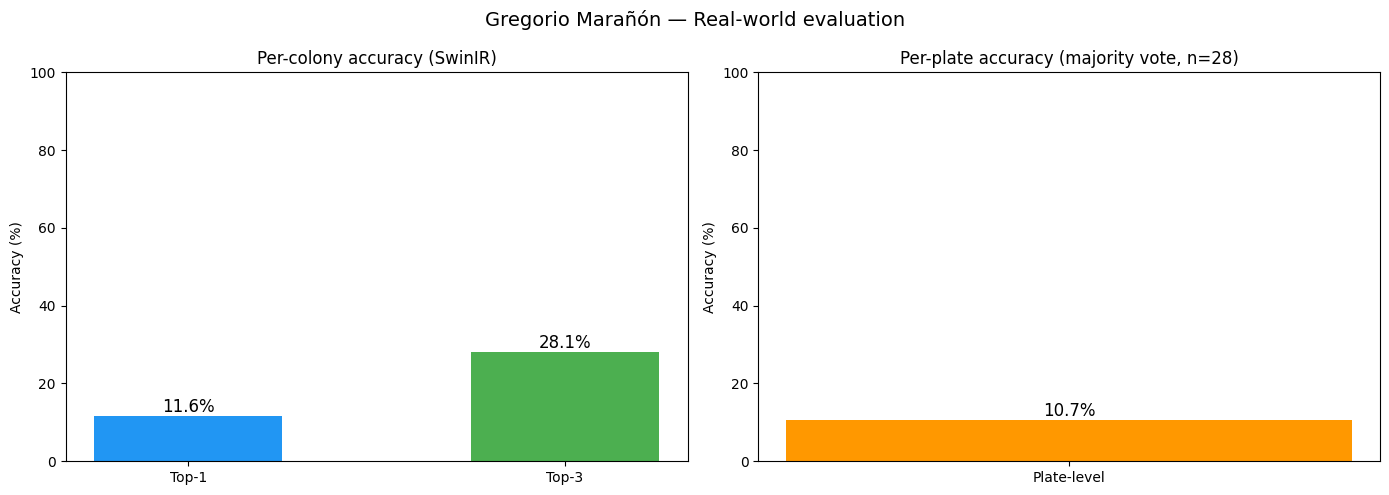

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Per-colony
bars1 = ax1.bar(["Top-1", "Top-3"], [top1_correct, top3_correct],
                color=["#2196F3", "#4CAF50"], width=0.5)
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Per-colony accuracy (SwinIR)")
ax1.set_ylim(0, 100)
for bar, val in zip(bars1, [top1_correct, top3_correct]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=12)

# Per-plate
bars2 = ax2.bar(["Plate-level"], [plate_acc], color=["#FF9800"], width=0.4)
ax2.set_ylabel("Accuracy (%)")
ax2.set_title(f"Per-plate accuracy (majority vote, n={plate_total})")
ax2.set_ylim(0, 100)
ax2.text(bars2[0].get_x() + bars2[0].get_width()/2, bars2[0].get_height() + 1,
         f'{plate_acc:.1f}%', ha='center', fontsize=12)

fig.suptitle("Gregorio Marañón — Real-world evaluation", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "maranon_evaluation.png"), dpi=150)
plt.show()

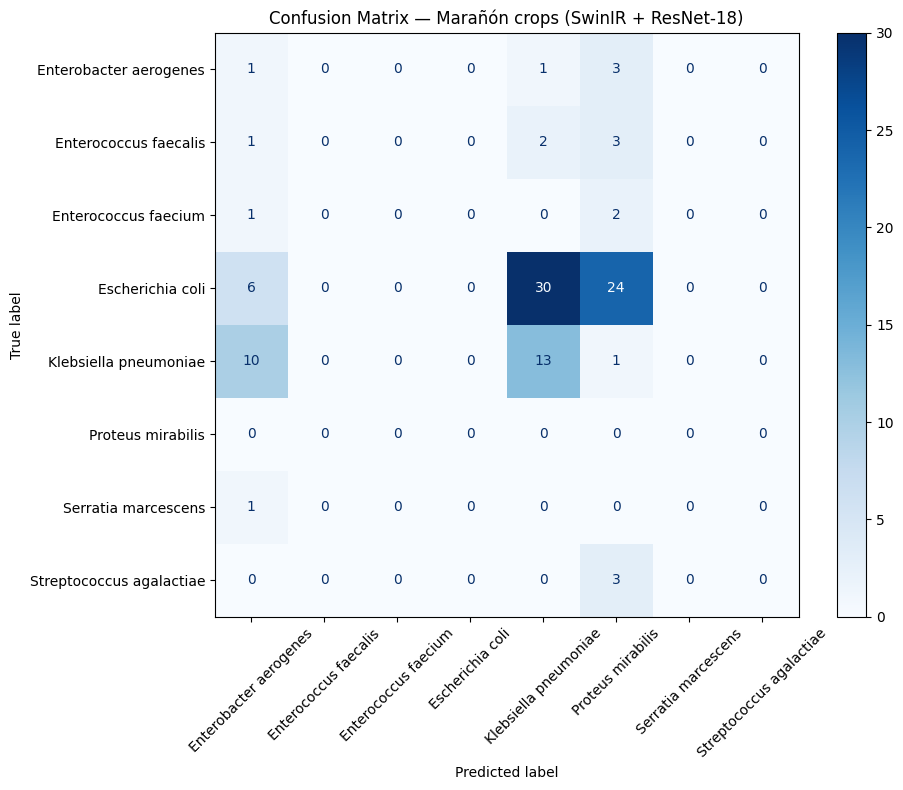

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Only species present in Marañón data
maranon_species = sorted(set(all_species))
maranon_indices = [MODEL_SPECIES_TO_IDX[s] for s in maranon_species]

cm = confusion_matrix(all_labels, all_preds, labels=maranon_indices)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=maranon_species)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — Marañón crops (SwinIR + ResNet-18)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Restricted evaluation: only 8 Marañón species considered
# ═══════════════════════════════════════════════════════════════

# Get indices of the 8 hospital species in the model's class space
maranon_species = sorted(set(all_species))
maranon_class_indices = [MODEL_SPECIES_TO_IDX[s] for s in maranon_species]

print("Restricting predictions to:")
for s, idx in zip(maranon_species, maranon_class_indices):
    print(f"  [{idx:>2}] {s}")

# Mask probabilities: zero out all classes except the 8 hospital species
restricted_probs = all_probs.copy()
mask = np.ones(restricted_probs.shape[1], dtype=bool)
mask[maranon_class_indices] = False
restricted_probs[:, mask] = 0  # zero out non-hospital species

# Re-normalize
row_sums = restricted_probs.sum(axis=1, keepdims=True)
restricted_probs = restricted_probs / (row_sums + 1e-9)

# Restricted predictions
restricted_preds = restricted_probs.argmax(axis=1)

# Per-colony accuracy
r_top1 = (restricted_preds == all_labels).mean() * 100
r_top3_idx = np.argsort(restricted_probs, axis=1)[:, -3:]
r_top3 = np.mean([all_labels[i] in r_top3_idx[i] for i in range(len(all_labels))]) * 100

print(f"\n{'='*60}")
print(f"  RESTRICTED TO 8 SPECIES vs FULL 32 CLASSES")
print(f"{'='*60}")
print(f"  {'Evaluation':<30} {'Top-1':>10} {'Top-3':>10}")
print(f"  {'-'*50}")
print(f"  {'Full 32 classes':<30} {top1_correct:>9.2f}% {top3_correct:>9.2f}%")
print(f"  {'Restricted to 8 species':<30} {r_top1:>9.2f}% {r_top3:>9.2f}%")
print(f"{'='*60}")

# Per-species breakdown (restricted)
print(f"\n{'Species':<30} {'Crops':>6} {'Full':>8} {'Restr.':>8}")
print("-" * 55)
for sp in maranon_species:
    sp_mask = np.array([s == sp for s in all_species])
    n = sp_mask.sum()
    full_acc = (all_preds[sp_mask] == all_labels[sp_mask]).mean() * 100
    rest_acc = (restricted_preds[sp_mask] == all_labels[sp_mask]).mean() * 100
    print(f"  {sp:<28} {n:>6} {full_acc:>7.1f}% {rest_acc:>7.1f}%")

# Per-plate majority vote (restricted)
plate_correct_r = 0
print(f"\n{'Plate':<30} {'True':<25} {'Predicted':<25} {'✓/✗'}")
print("-" * 85)
for plate in sorted(set(all_plates)):
    pmask = np.array([p == plate for p in all_plates])
    plate_rpreds = restricted_preds[pmask]
    plate_label = all_labels[pmask][0]
    vote = Counter(plate_rpreds).most_common(1)[0][0]
    true_name = MODEL_IDX_TO_SPECIES.get(str(plate_label), MODEL_IDX_TO_SPECIES.get(plate_label, "?"))
    pred_name = MODEL_IDX_TO_SPECIES.get(str(vote), MODEL_IDX_TO_SPECIES.get(vote, "?"))
    correct = vote == plate_label
    if correct: plate_correct_r += 1
    mark = "✓" if correct else "✗"
    print(f"  {plate:<28} {true_name:<23} {pred_name:<23} {mark} ({pmask.sum()} crops)")

n_plates = len(set(all_plates))
print(f"\n  Plate-level: {plate_correct_r}/{n_plates} = {plate_correct_r/n_plates*100:.1f}%")
print(f"  (was {3}/{n_plates} = {3/n_plates*100:.1f}% with full 32 classes)")

Restricting predictions to:
  [ 8] Enterobacter aerogenes
  [10] Enterococcus faecalis
  [11] Enterococcus faecium
  [12] Escherichia coli
  [14] Klebsiella pneumoniae
  [17] Proteus mirabilis
  [20] Serratia marcescens
  [26] Streptococcus agalactiae

  RESTRICTED TO 8 SPECIES vs FULL 32 CLASSES
  Evaluation                          Top-1      Top-3
  --------------------------------------------------
  Full 32 classes                    11.57%     28.10%
  Restricted to 8 species            14.05%     29.75%

Species                         Crops     Full   Restr.
-------------------------------------------------------
  Enterobacter aerogenes            5    20.0%    20.0%
  Enterococcus faecalis             6     0.0%     0.0%
  Enterococcus faecium              3     0.0%     0.0%
  Escherichia coli                 69     0.0%     0.0%
  Klebsiella pneumoniae            25    52.0%    56.0%
  Proteus mirabilis                 6     0.0%    33.3%
  Serratia marcescens              